# Understanding Toxicity Behaviour in the League of Legends Video Game

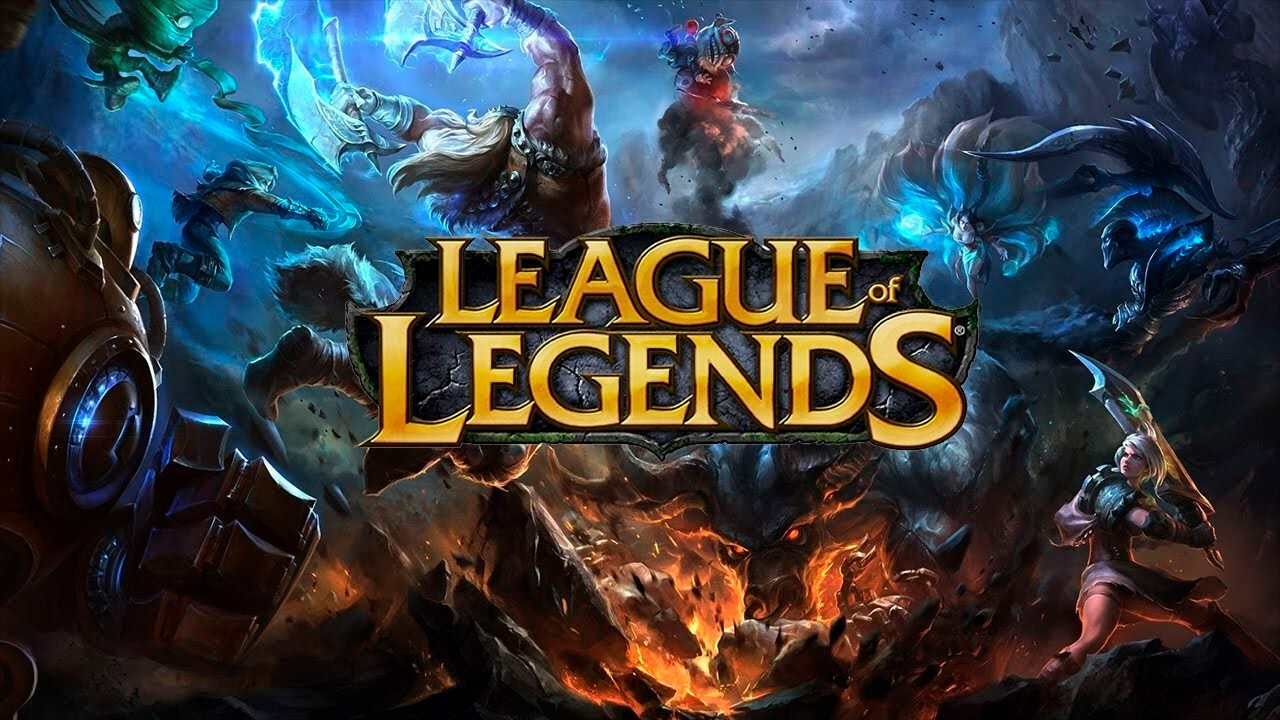

Source: https://www.instant-gaming.com/pl/9456-pobierz-league-of-legends-pc-game/?srsltid=AfmBOoqL7AXapiP7FBnAYtOD08S3M-PMo_DV3FdVGM0K6IcVxkwm1LMF

## Section 1: Introduction and Research Question

In the popular video game League of Legends, developed and published by Riot Games, players have to .... 5v5 each other ... Revenue can be generated from buying skins etc?

Toxic players are those who purposely do .... to make their team lose. 

Identifying toxic players is a difficult but important task for gaming companies like Riot Games, as players never self-identify as toxic and their behavior must be inferred from gameplay data. From a profit generation perspective, it is in the interest of gaming companies to understand toxicity as it significantly reduces player retention due to poor community health. Toxic players drive away other regular players, resulting in less retention, engagement, and spending from regular players. Therefore, with this business use-case in mind, we find it meaningful to understand toxicity in a popular team-based game like League of Legends, resulting in our formulation of the research questions listed below.

<font color="red"> NOTE: We can add some references on LoL reputation for having toxic players? or investing in researching in this field? any statements/articles they've published would support this use-case  <font color="black">

Research Questions:
1. What factors affect toxicity.....
2. ....


## Section 2: Prerequisites for Notebook

Please ensure necessary libraries are installed on your environment. Here is a list of less common libraries you will need to run this notebook:
1. ...


In [ ]:
#pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.5/534.5 kB 10.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 9.9 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [datasets]/20 [datasets]ce-hub]
Note: you may need to restart the kernel to use updated packages.


In [135]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import time
import json
import requests
from tqdm import tqdm

## Section 3: Data Preprocessing - Load Data

### 3.1: Load matches, participants, and events data from HuggingFace

Purpose:<font color="red"> write something!<font color="black"> 

Method: Load data using `datasets` library

Source: https://huggingface.co/datasets/gptilt/lol-basic-matches-challenger-10k

In [2]:
# Load token
token_file = open("ST445_Project_hf token.txt")
token_hf = token_file.read()

In [3]:
# Login to HuggingFace website
from huggingface_hub import login
login(token=token_hf)

In [4]:
# Load matches data
data_matches = load_dataset("gptilt/lol-basic-matches-challenger-10k", "matches")

# Get americas data and convert to pandas 
df_matches_amer = data_matches['region_americas'].to_pandas()

# Check data
df_matches_amer

,endOfGameResult,gameDuration,gameEndTimestamp,gameId,gameStartTimestamp,gameVersion,matchId,platformId,region,team_100_EPIC_MONSTER_KILL,...,team_200_horde_first,team_200_horde_kills,team_200_inhibitor_first,team_200_inhibitor_kills,team_200_riftHerald_first,team_200_riftHerald_kills,team_200_tower_first,team_200_tower_kills,tournamentCode,winner_team_id
0,GameComplete,1400,1745018960446,5269865992,1745017559681,15.8.675.10,NA1_5269865992,NA1,americas,3,...,False,0,False,0,False,0,False,2,,100
1,GameComplete,1524,1744589457829,5266494442,1744587933314,15.7.672.4034,NA1_5266494442,NA1,americas,2,...,True,5,True,1,False,0,False,8,,200
2,GameComplete,1782,1744585171830,5266444763,1744583389986,15.7.672.4034,NA1_5266444763,NA1,americas,2,...,True,1,False,0,False,0,False,2,,100
3,GameComplete,1939,1744582474913,5266408515,1744580535842,15.7.672.4034,NA1_5266408515,NA1,americas,1001,...,False,3,True,1,False,0,False,8,,200
4,GameComplete,930,1744576222010,5266355238,1744575291787,15.7.672.4034,NA1_5266355238,NA1,americas,1,...,False,0,False,0,False,0,True,3,,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,GameComplete,1306,1744695473229,1612786876,1744694166406,15.7.672.4034,LA1_1612786876,LA1,americas,1001,...,True,6,False,0,True,1,True,5,,200
3330,GameComplete,1517,1744690271585,1612758933,1744688754314,15.7.672.4034,LA1_1612758933,LA1,americas,1,...,True,3,True,2,False,0,False,7,,200
3331,GameComplete,1837,1744872208317,1613288313,1744870371493,15.8.673.8244,LA1_1613288313,LA1,americas,2,...,True,3,False,0,True,1,True,5,,100
3332,GameComplete,1902,1744776848623,1613000432,1744774946027,15.7.672.4034,LA1_1613000432,LA1,americas,3,...,False,0,True,2,False,0,False,10,,200


In [5]:
# Get columns from matches df
print("Matches Columns:")
print(df_matches_amer.columns)

Matches Columns:
Index(['endOfGameResult', 'gameDuration', 'gameEndTimestamp', 'gameId',
       'gameStartTimestamp', 'gameVersion', 'matchId', 'platformId', 'region',
       'team_100_EPIC_MONSTER_KILL', 'team_100_FIRST_BLOOD',
       'team_100_FIRST_TURRET', 'team_100_atakhan_first',
       'team_100_atakhan_kills', 'team_100_baron_first',
       'team_100_baron_kills', 'team_100_champion_first',
       'team_100_champion_kills', 'team_100_dragon_first',
       'team_100_dragon_kills', 'team_100_horde_first', 'team_100_horde_kills',
       'team_100_inhibitor_first', 'team_100_inhibitor_kills',
       'team_100_riftHerald_first', 'team_100_riftHerald_kills',
       'team_100_tower_first', 'team_100_tower_kills',
       'team_200_EPIC_MONSTER_KILL', 'team_200_FIRST_BLOOD',
       'team_200_FIRST_TURRET', 'team_200_atakhan_first',
       'team_200_atakhan_kills', 'team_200_baron_first',
       'team_200_baron_kills', 'team_200_champion_first',
       'team_200_champion_kills', 'team_20

In [ ]:
# Save to CSV for analysis
# df_matches_amer.to_csv("hf_matches.csv", index=False)
# print("Saved file: hf_matches.csv")

Saved file: hf_matches.csv


### 3.2: Load actual player behavior in games from Riot Games

Purpose:<font color="red"> write something!<font color="black"> 

Method: API Calls

Source: <font color="red"> insert link!<font color="black"> 

In [ ]:
# Load API Key
api_file = open("ST445_Project_Riot API Key.txt")
RIOT_API_KEY = api_file.read()

In [11]:
# Get match IDs
match_ids = df_matches_amer['matchId'].tolist()

def get_match_details(match_id, region='americas'):
    """Fetch match details from Riot API"""
    url = f"https://{region}.api.riotgames.com/lol/match/v5/matches/{match_id}"
    headers = {"X-Riot-Token": RIOT_API_KEY}
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:  # Rate limit
        time.sleep(2)
        return get_match_details(match_id, region)
    else:
        print(f"Error {response.status_code} for match {match_id}")
        return None

def get_match_timeline(match_id, region='americas'):
    """Fetch match timeline from Riot API"""
    url = f"https://{region}.api.riotgames.com/lol/match/v5/matches/{match_id}/timeline"
    headers = {"X-Riot-Token": RIOT_API_KEY}
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:  # Rate limit
        time.sleep(2)
        return get_match_timeline(match_id, region)
    else:
        print(f"Error {response.status_code} for timeline {match_id}")
        return None

def extract_player_features(match_data, timeline_data):
    """Extract all white-label features for each player including 15min data and surrender info"""
    players = []
    
    info = match_data['info']
    match_id = match_data['metadata']['matchId']
    
    # Extract surrender information (same for all players in the match)
    game_ended_in_surrender = info['participants'][0].get('gameEndedInSurrender', False)
    game_ended_in_early_surrender = info['participants'][0].get('gameEndedInEarlySurrender', False)
    
    # Calculate surrender time
    if game_ended_in_surrender or game_ended_in_early_surrender:
        surrender_time_minutes = info['gameDuration'] / 60
    else:
        surrender_time_minutes = None
    
    # Extract 15min data from timeline
    player_15min_data = {}
    player_inventory = {i: [] for i in range(1, 11)}
    
    if timeline_data:
        for frame in timeline_data['info']['frames']:
            timestamp_min = frame['timestamp'] / 60000
            
            # Capture stats at 15min
            if 14.5 <= timestamp_min <= 15.5:
                for pid_str, pframe in frame['participantFrames'].items():
                    pid = int(pid_str)
                    player_15min_data[pid] = {
                        'level_15min': pframe['level'],
                        'gold_15min': pframe['totalGold'],
                        'cs_15min': pframe['minionsKilled'] + pframe['jungleMinionsKilled']
                    }
            
            if timestamp_min > 15:
                break
            
            # Track current inventory (not purchase history)
            for event in frame.get('events', []):
                pid = event.get('participantId')
                if not pid:
                    continue
                
                if event['type'] == 'ITEM_PURCHASED':
                    player_inventory[pid].append(event['itemId'])
                
                elif event['type'] == 'ITEM_SOLD':
                    if event['itemId'] in player_inventory[pid]:
                        player_inventory[pid].remove(event['itemId'])
                
                elif event['type'] == 'ITEM_DESTROYED':
                    if event['itemId'] in player_inventory[pid]:
                        player_inventory[pid].remove(event['itemId'])
                
                elif event['type'] == 'ITEM_UNDO':
                    before = event.get('beforeId')
                    after = event.get('afterId')
                    if before and before in player_inventory[pid]:
                        player_inventory[pid].remove(before)
                    if after and after != 0:
                        player_inventory[pid].append(after)
    
    # Build player features
    for participant in info['participants']:
        participant_id = participant['participantId']
        
        # Get 15min data for this participant
        data_15min = player_15min_data.get(participant_id, {})
        items_15min = ','.join(map(str, player_inventory.get(participant_id, []))) if player_inventory.get(participant_id) else None
        
        player = {
            'matchId': match_id,
            'puuid': participant['puuid'],
            
            # Performance stats
            'kills': participant['kills'],
            'deaths': participant['deaths'],
            'assists': participant['assists'],
            'kda': (participant['kills'] + participant['assists']) / max(participant['deaths'], 1),
            'teamPosition': participant.get('teamPosition', ''),
            'individualPosition': participant.get('individualPosition', ''),
            
            # Combat metrics
            'totalDamageDealtToChampions': participant['totalDamageDealtToChampions'],
            'totalDamageTaken': participant['totalDamageTaken'],
            
            # Economy
            'goldEarned': participant['goldEarned'],
            'totalMinionsKilled': participant['totalMinionsKilled'],
            'neutralMinionsKilled': participant['neutralMinionsKilled'],
            
            # Vision control
            'visionScore': participant['visionScore'],
            'wardsPlaced': participant['wardsPlaced'],
            'wardsKilled': participant['wardsKilled'],
            
            # Objectives
            'turretKills': participant['turretKills'],
            'inhibitorKills': participant['inhibitorKills'],
            'firstBloodKill': participant['firstBloodKill'],
            
            # Team contribution
            'killParticipation': participant.get('challenges', {}).get('killParticipation', 0),
            'teamDamagePercentage': participant.get('challenges', {}).get('teamDamagePercentage', 0),
            
            # Champion info
            'championName': participant['championName'],
            'championId': participant['championId'],
            
            # Game outcome
            'win': participant['win'],
            'gameDuration': info['gameDuration'],
            
            # 15-minute snapshot data
            'items_15min': items_15min,
            'level_15min': data_15min.get('level_15min'),
            'gold_15min': data_15min.get('gold_15min'),
            'cs_15min': data_15min.get('cs_15min'),
            
            # Surrender information
            'gameEndedInSurrender': game_ended_in_surrender,
            'gameEndedInEarlySurrender': game_ended_in_early_surrender,
            'surrenderTime_minutes': surrender_time_minutes
        }
        
        # Calculate per-minute stats
        duration_min = info['gameDuration'] / 60
        player['csPerMinute'] = (player['totalMinionsKilled'] + player['neutralMinionsKilled']) / duration_min
        player['goldPerMinute'] = player['goldEarned'] / duration_min
        player['visionScorePerMinute'] = player['visionScore'] / duration_min
        
        players.append(player)
    
    return players

# Collect data
all_players = []

for match_id in tqdm(match_ids):
    match_data = get_match_details(match_id)
    
    if match_data:
        timeline_data = get_match_timeline(match_id)
        players = extract_player_features(match_data, timeline_data)
        all_players.extend(players)
    
    time.sleep(1.2)  # Rate limit: be safe with 1.2s between requests

# Create DataFrame
df_players = pd.DataFrame(all_players)
df_players.to_csv("lol_player_features.csv", index=False)

print(f"\nCollected data for {len(df_players)} players across {len(df_players['matchId'].unique())} matches")
print(f"\nColumns: {df_players.columns.tolist()}")
print(f"\nSample:")
print(df_players.head())

100%|██████████| 3334/3334 [2:15:38<00:00,  2.44s/it]  



Collected data for 33340 players across 3334 matches

Columns: ['matchId', 'puuid', 'kills', 'deaths', 'assists', 'kda', 'teamPosition', 'individualPosition', 'totalDamageDealtToChampions', 'totalDamageTaken', 'goldEarned', 'totalMinionsKilled', 'neutralMinionsKilled', 'visionScore', 'wardsPlaced', 'wardsKilled', 'turretKills', 'inhibitorKills', 'firstBloodKill', 'killParticipation', 'teamDamagePercentage', 'championName', 'championId', 'win', 'gameDuration', 'items_15min', 'level_15min', 'gold_15min', 'cs_15min', 'gameEndedInSurrender', 'gameEndedInEarlySurrender', 'surrenderTime_minutes', 'csPerMinute', 'goldPerMinute', 'visionScorePerMinute']

Sample:
          matchId                                              puuid  kills  \
0  NA1_5269865992  Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...      4   
1  NA1_5269865992  199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...      5   
2  NA1_5269865992  dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...      5   
3  NA1_5269865992  G

In League of Legends, boots items grant movement speed but do not provide additional value when multiple pairs are purchased simultaneously. Under standard gameplay, players typically purchase at most one boots item before investing in role-specific core items. Acquiring two or more boots therefore represents a clear departure from rational itemisation.

Accordingly, we **define a troll build as any instance in which a player possesses two or more boots items at the 15-minute mark**, a stage by which structured item builds are expected to emerge. This behaviour is rare, role-agnostic, and difficult to justify through normal gameplay considerations, making it a suitable proxy for intentional disruptive behaviour to be used in the next section for toxicity analysis.

**<span style="color:red"> can we move this part to section 4.3? it seems more like processing data, not just loading <span style="color:black">**

In [12]:
# adding flag for if player has bought 2+ boots at the 15min mark (FLAG IN ASSUMPTIONS) -> troll build

BOOT_ITEMS = {
    1001,  # Boots
    3005,  # Slightly Magical Boots (Rune)
    3006,  # Berserker's Greaves
    3009,  # Boots of Swiftness
    3020,  # Sorcerer's Shoes
    3047,  # Plated Steelcaps
    3111,  # Mercury's Treads
    3112,  # Symbiotic Soles (Replaces 3112 Guardian's Orb from ARAM)
    3117,  # Mobility Boots
    3158,  # Ionian Boots of Lucidity
    3160,  # Crimson Lucidity
    3161,  # Swiftmarch
    3162,  # Spellslinger's Shoes
    3163,  # Gunmetal Greaves
    3164,  # Chainlaced Crushers
    3165,  # Armored Advance
    3172   # Zephyr
}

troll_build_list = []

for idx, row in df_players.iterrows():
    items_15min = row['items_15min']
    
    if pd.notna(items_15min):
        # Split the items string and convert to integers
        items = [int(i) for i in str(items_15min).split(',') if i.strip().isdigit()]
        
        # Count how many boots
        boot_count = sum(1 for item in items if item in BOOT_ITEMS)
        
        # PROXY + ASSUMPTION: 2+ boots = troll build
        troll_build_list.append(boot_count >= 2)
    else:
        troll_build_list.append(False)

# Add to dataframe
df_players['trollBuild_15min'] = troll_build_list

# Check results
print(f"✅ Troll build detection complete!")
print(f"Total troll builds detected: {df_players['trollBuild_15min'].sum()}")
print(f"Percentage: {df_players['trollBuild_15min'].sum() / len(df_players) * 100:.2f}%")
print(f"\nSample of troll builds:")
print(df_players[df_players['trollBuild_15min'] == True][['matchId', 'championName', 'items_15min', 'trollBuild_15min']].head())

✅ Troll build detection complete!
Total troll builds detected: 158
Percentage: 0.47%

Sample of troll builds:
            matchId championName                         items_15min  \
82   NA1_5265904325        Jayce  1055,3070,2031,3161,3111,1036,3363   
91   NA1_5267244886        Poppy  1102,1001,2022,3364,3161,1033,1028   
475  NA1_5269646969        Jayce       1055,2031,3161,3004,1001,3363   
605  NA1_5260870044        Jayce  1055,3340,2031,3070,1033,3161,1001   
722  NA1_5259240397        Jayce  1055,3070,2031,1001,3161,3363,1036   

     trollBuild_15min  
82               True  
91               True  
475              True  
605              True  
722              True  


In [14]:
df_players.to_csv("lol_player_features.csv", index=False)
df_players.head(5)

,matchId,puuid,kills,deaths,assists,kda,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,level_15min,gold_15min,cs_15min,gameEndedInSurrender,gameEndedInEarlySurrender,surrenderTime_minutes,csPerMinute,goldPerMinute,visionScorePerMinute,trollBuild_15min
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,TOP,12816,14985,...,11.0,6539.0,136.0,True,False,23.333333,9.857143,467.828571,0.514286,False
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,MIDDLE,20310,21173,...,10.0,5639.0,118.0,True,False,23.333333,7.800000,397.671429,0.642857,False
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,JUNGLE,18560,30340,...,10.0,5792.0,104.0,True,False,23.333333,7.285714,433.628571,0.728571,False
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,BOTTOM,14190,14449,...,9.0,5170.0,129.0,True,False,23.333333,7.842857,381.557143,0.300000,False
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,UTILITY,21288,26427,...,8.0,5228.0,19.0,True,False,23.333333,1.414286,359.485714,2.400000,False


### 3.3: Load champion data to get psychological features from Data Dragon json file

Purpose:<font color="red"> write something!<font color="black"> 

Method: Load json data from url 

Source: <font color="red"> insert link!<font color="black"> 

In [15]:
url = "https://ddragon.leagueoflegends.com/cdn/15.17.1/data/en_US/champion.json"

# Get json data
get_json = requests.get(url)
champion = get_json.json()

# Change data to pd format
df_champion = pd.DataFrame(champion['data'].values())

In [16]:
# Columns to expand as they contain multiple features
expand_columns = ['info', 'image', 'stats']

for c in expand_columns:
    # Expand column
    df_temp = df_champion[c].apply(pd.Series)

    # Add columns to main df_champion
    df_champion = pd.concat([df_champion, df_temp], axis=1)

    # Drop original column
    df_champion = df_champion.drop(c, axis=1)

In [17]:
# Display df_champion
df_champion

,version,id,key,name,title,blurb,tags,partype,attack,defense,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
0,15.17.1,Aatrox,266,Aatrox,the Darkin Blade,Once honored defenders of Shurima against the ...,[Fighter],Blood Well,8,4,...,3.00,0.50,0.00,0.00,0.0,0.0,60.0,5.00,2.500,0.651
1,15.17.1,Ahri,103,Ahri,the Nine-Tailed Fox,Innately connected to the magic of the spirit ...,"[Mage, Assassin]",Mana,3,4,...,2.50,0.60,8.00,0.80,0.0,0.0,53.0,3.00,2.200,0.668
2,15.17.1,Akali,84,Akali,the Rogue Assassin,Abandoning the Kinkou Order and her title of t...,[Assassin],Energy,5,3,...,9.00,0.90,50.00,0.00,0.0,0.0,62.0,3.30,3.200,0.625
3,15.17.1,Akshan,166,Akshan,the Rogue Sentinel,"Raising an eyebrow in the face of danger, Aksh...","[Marksman, Assassin]",Mana,0,0,...,3.75,0.65,8.20,0.70,0.0,0.0,52.0,3.00,4.000,0.638
4,15.17.1,Alistar,12,Alistar,the Minotaur,Always a mighty warrior with a fearsome reputa...,"[Tank, Support]",Mana,6,9,...,8.50,0.85,8.50,0.80,0.0,0.0,62.0,3.75,2.125,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,15.17.1,Zeri,221,Zeri,The Spark of Zaun,"A headstrong, spirited young woman from Zaun's...",[Marksman],Mana,8,5,...,3.25,0.70,6.00,0.80,0.0,0.0,56.0,2.00,2.000,0.658
167,15.17.1,Ziggs,115,Ziggs,the Hexplosives Expert,"With a love of big bombs and short fuses, the ...",[Mage],Mana,2,4,...,6.50,0.60,8.00,0.80,0.0,0.0,55.0,3.10,2.000,0.656
168,15.17.1,Zilean,26,Zilean,the Chronokeeper,"Once a powerful Icathian mage, Zilean became o...","[Support, Mage]",Mana,2,5,...,5.50,0.50,11.35,0.80,0.0,0.0,52.0,3.00,2.130,0.658
169,15.17.1,Zoe,142,Zoe,the Aspect of Twilight,"As the embodiment of mischief, imagination, an...",[Mage],Mana,1,7,...,7.50,0.60,8.00,0.65,0.0,0.0,58.0,3.30,2.500,0.658


In [18]:
# Get columns from events df
print("Champion Columns:")
print(df_champion.columns)

Champion Columns:
Index(['version', 'id', 'key', 'name', 'title', 'blurb', 'tags', 'partype',
       'attack', 'defense', 'magic', 'difficulty', 'full', 'sprite', 'group',
       'x', 'y', 'w', 'h', 'hp', 'hpperlevel', 'mp', 'mpperlevel', 'movespeed',
       'armor', 'armorperlevel', 'spellblock', 'spellblockperlevel',
       'attackrange', 'hpregen', 'hpregenperlevel', 'mpregen',
       'mpregenperlevel', 'crit', 'critperlevel', 'attackdamage',
       'attackdamageperlevel', 'attackspeedperlevel', 'attackspeed'],
      dtype='object')


In [ ]:
# Save to CSV for analysis
# df_champion.to_csv("dd_champions.csv", index=False)
# print("Saved file: dd_champions.csv")

Saved file: dd_champions.csv


### 3.4: Web scrape champion-level metadata statistics from OP.GG

Purpose:<font color="red"> write something!<font color="black"> 

Method: 
Champion statistics are extracted by parsing embedded JSON data contained in the OP.GG statistics page HTML.
For each role (top, jungle, middle, bottom, support), the script identifies the JSON block corresponding to champion performance metrics and aggregates win rate, pick rate, ban rate, and usage indicators into a structured dataset.

Source: <font color="red"> insert link!<font color="black"> 
OP.GG - League of Legends Champion Statistics
https://op.gg/lol/statistics/champions

In [19]:
BASE_URL = "https://op.gg/lol/statistics/champions"
REGION = "na"  # Only used for the request parameters
POSITIONS = ["top", "jungle", "mid", "adc", "support"]

# Headers to mimic a real browser and avoid 403 Forbidden errors
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://op.gg/",
}

decoder = json.JSONDecoder()
all_rows = []

for pos in POSITIONS:
    print(f"\n=== Scraping Position: {pos} ===")

    res = requests.get(
        BASE_URL,
        params={"region": REGION, "position": pos, "tier": "challenger"},
        headers=headers,
        timeout=20,
    )
    res.raise_for_status()
    html = res.text

    # ------------------------------------------------------------
    # LOGIC: Locate all "[{" patterns in the HTML as potential candidates.
    # We attempt to parse (raw_decode) from those points and select the 
    # block that looks like the "Champion Statistics List."
    # ------------------------------------------------------------

    data = None
    idx = 0

    while True:
        start = html.find("[{", idx)
        if start == -1:
            break

        # Extract the chunk starting from "[{". We handle escaped quotes 
        # to ensure it's valid JSON format.
        chunk = html[start:].replace('\\"', '"')

        try:
            parsed, _ = decoder.raw_decode(chunk)
        except json.JSONDecodeError:
            idx = start + 2
            continue

        # Validate if the parsed JSON is the champion statistics list we want:
        # 1. It must be a list.
        # 2. It must not be empty.
        # 3. The first element should contain a 'champion' dictionary.
        # 4. It should contain win/pick/ban rates (supporting both snake_case and camelCase).
        if (
            isinstance(parsed, list)
            and len(parsed) > 0
            and isinstance(parsed[0], dict)
            and isinstance(parsed[0].get("champion"), dict)
        ):
            keys = set(parsed[0].keys())
            has_rates = (
                ("win_rate" in keys or "pick_rate" in keys or "ban_rate" in keys) or
                ("winRate" in keys or "pickRate" in keys or "banRate" in keys)
            )

            if has_rates:
                data = parsed
                print("Found champion stats block at start index:", start)
                print("Example data keys:", parsed[0].keys())
                break

        idx = start + 2

    if data is None:
        raise ValueError(f"Could not find champion stats JSON block for position={pos}.")

    # ------------------------------------------------------------
    # Process the extracted data into rows.
    # We account for both snake_case and camelCase naming conventions.
    # ------------------------------------------------------------
    for x in data:
        champ = x.get("champion", {})

        all_rows.append({
            "position": pos,
            "champion": champ.get("name"),
            "key": champ.get("key"),
            "games_played": x.get("play") or x.get("games") or x.get("gamesPlayed"),
            "kda": x.get("kda") or x.get("kdaRatio"),
            "win_rate": x.get("win_rate", x.get("winRate")),
            "pick_rate": x.get("pick_rate", x.get("pickRate")),
            "ban_rate": x.get("ban_rate", x.get("banRate")),
            "cs": x.get("cs"),
            "gold": x.get("gold"),
        })

    # Respectful pause to prevent rate limiting
    time.sleep(0.4)

# Create and organize the DataFrame
df = pd.DataFrame(all_rows)
df = df[
    ["position", "champion", "key",
     "games_played", "kda", "win_rate", "pick_rate", "ban_rate",
     "cs", "gold"]
]

display(df.head(10))
print("Total rows collected:", len(df))


=== Scraping Position: top ===
Found champion stats block at start index: 505435
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: jungle ===
Found champion stats block at start index: 505444
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: mid ===
Found champion stats block at start index: 505438
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: adc ===
Found champion stats block at start index: 505438
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: support ===
Found champion stats block at start index: 505447
Example data keys: dict_keys(['champion

,position,champion,key,games_played,kda,win_rate,pick_rate,ban_rate,cs,gold
0,top,Diana,diana,12,1.18,16.666667,0.99,5.77,179.17,10226
1,top,Syndra,syndra,6,1.89,16.666667,1.50,8.73,246.50,14188
2,top,Smolder,smolder,15,1.52,20.000000,1.53,0.94,196.47,11558
3,top,Volibear,volibear,8,1.63,25.000000,0.82,0.25,165.25,9921
4,top,Twisted Fate,twistedfate,4,2.21,25.000000,1.08,0.32,195.50,11967
5,top,Zed,zed,15,1.86,26.666667,1.45,10.86,210.60,11885
6,top,Karma,karma,7,1.46,28.571429,0.84,2.21,174.14,9078
7,top,Poppy,poppy,49,2.11,32.653061,2.53,7.44,194.78,10989
8,top,Rek'Sai,reksai,12,1.67,33.333333,1.03,0.85,219.25,12433
9,top,Zilean,zilean,6,4.79,33.333333,0.86,3.16,214.33,10612


Total rows collected: 507


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   position      507 non-null    object 
 1   champion      507 non-null    object 
 2   key           507 non-null    object 
 3   games_played  507 non-null    int64  
 4   kda           507 non-null    object 
 5   win_rate      507 non-null    float64
 6   pick_rate     507 non-null    float64
 7   ban_rate      507 non-null    object 
 8   cs            507 non-null    float64
 9   gold          507 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 39.7+ KB


In [21]:
df.isna().sum()

position        0
champion        0
key             0
games_played    0
kda             0
win_rate        0
pick_rate       0
ban_rate        0
cs              0
gold            0
dtype: int64

In [22]:
# convert string NaN to np.nan for ban_rate
df["ban_rate"] = (
    df["ban_rate"]
    .replace(["NaN", "$NaN", "nan"], np.nan)
)

df["ban_rate"] = pd.to_numeric(df["ban_rate"], errors="coerce")

In [23]:
# 39 missing values in ban_rate 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   position      507 non-null    object 
 1   champion      507 non-null    object 
 2   key           507 non-null    object 
 3   games_played  507 non-null    int64  
 4   kda           507 non-null    object 
 5   win_rate      507 non-null    float64
 6   pick_rate     507 non-null    float64
 7   ban_rate      470 non-null    float64
 8   cs            507 non-null    float64
 9   gold          507 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 39.7+ KB


In [ ]:
# Save to CSV for analysis
# df.to_csv("opgg_champions_all_positions_challengers.csv", index=False)
# print("Saved file: opgg_champions_all_positions_challengers.csv")

Saved file: opgg_champions_all_positions_challengers.csv


## Section 4: Data Preprocessing - Data Cleaning

### 4.1: Merge all 4 DataFrames

#### View all 4 DataFrames to identify common columns for merging

In [99]:
# HuggingFace Match Data
df_matches_amer = pd.read_csv('hf_matches.csv')
df_matches_amer

,endOfGameResult,gameDuration,gameEndTimestamp,gameId,gameStartTimestamp,gameVersion,matchId,platformId,region,team_100_EPIC_MONSTER_KILL,...,team_200_horde_first,team_200_horde_kills,team_200_inhibitor_first,team_200_inhibitor_kills,team_200_riftHerald_first,team_200_riftHerald_kills,team_200_tower_first,team_200_tower_kills,tournamentCode,winner_team_id
0,GameComplete,1400,1745018960446,5269865992,1745017559681,15.8.675.10,NA1_5269865992,NA1,americas,3,...,False,0,False,0,False,0,False,2,NaN,100
1,GameComplete,1524,1744589457829,5266494442,1744587933314,15.7.672.4034,NA1_5266494442,NA1,americas,2,...,True,5,True,1,False,0,False,8,NaN,200
2,GameComplete,1782,1744585171830,5266444763,1744583389986,15.7.672.4034,NA1_5266444763,NA1,americas,2,...,True,1,False,0,False,0,False,2,NaN,100
3,GameComplete,1939,1744582474913,5266408515,1744580535842,15.7.672.4034,NA1_5266408515,NA1,americas,1001,...,False,3,True,1,False,0,False,8,NaN,200
4,GameComplete,930,1744576222010,5266355238,1744575291787,15.7.672.4034,NA1_5266355238,NA1,americas,1,...,False,0,False,0,False,0,True,3,NaN,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,GameComplete,1306,1744695473229,1612786876,1744694166406,15.7.672.4034,LA1_1612786876,LA1,americas,1001,...,True,6,False,0,True,1,True,5,NaN,200
3330,GameComplete,1517,1744690271585,1612758933,1744688754314,15.7.672.4034,LA1_1612758933,LA1,americas,1,...,True,3,True,2,False,0,False,7,NaN,200
3331,GameComplete,1837,1744872208317,1613288313,1744870371493,15.8.673.8244,LA1_1613288313,LA1,americas,2,...,True,3,False,0,True,1,True,5,NaN,100
3332,GameComplete,1902,1744776848623,1613000432,1744774946027,15.7.672.4034,LA1_1613000432,LA1,americas,3,...,False,0,True,2,False,0,False,10,NaN,200


In [100]:
# Riot Player Statistics Data
df_players = pd.read_csv('lol_player_features.csv')
df_players

,matchId,puuid,kills,deaths,assists,kda,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,level_15min,gold_15min,cs_15min,gameEndedInSurrender,gameEndedInEarlySurrender,surrenderTime_minutes,csPerMinute,goldPerMinute,visionScorePerMinute,trollBuild_15min
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,TOP,12816,14985,...,11.0,6539.0,136.0,True,False,23.333333,9.857143,467.828571,0.514286,False
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,MIDDLE,20310,21173,...,10.0,5639.0,118.0,True,False,23.333333,7.800000,397.671429,0.642857,False
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,JUNGLE,18560,30340,...,10.0,5792.0,104.0,True,False,23.333333,7.285714,433.628571,0.728571,False
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,BOTTOM,14190,14449,...,9.0,5170.0,129.0,True,False,23.333333,7.842857,381.557143,0.300000,False
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,UTILITY,21288,26427,...,8.0,5228.0,19.0,True,False,23.333333,1.414286,359.485714,2.400000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,TOP,13003,23171,...,10.0,4830.0,83.0,False,False,NaN,6.270968,394.180645,0.851613,False
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,JUNGLE,23432,31388,...,10.0,6973.0,85.0,False,False,NaN,6.000000,485.032258,0.812903,False
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,MIDDLE,31643,14938,...,11.0,6494.0,119.0,False,False,NaN,7.819355,490.606452,1.200000,False
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,BOTTOM,16886,17398,...,10.0,6499.0,126.0,False,False,NaN,8.206452,482.477419,0.580645,False


In [101]:
# Data Dragon Overall Champions Data
df_champion = pd.read_csv('dd_champions.csv')
df_champion

,version,id,key,name,title,blurb,tags,partype,attack,defense,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
0,15.17.1,Aatrox,266,Aatrox,the Darkin Blade,Once honored defenders of Shurima against the ...,['Fighter'],Blood Well,8,4,...,3.00,0.50,0.00,0.00,0.0,0.0,60.0,5.00,2.500,0.651
1,15.17.1,Ahri,103,Ahri,the Nine-Tailed Fox,Innately connected to the magic of the spirit ...,"['Mage', 'Assassin']",Mana,3,4,...,2.50,0.60,8.00,0.80,0.0,0.0,53.0,3.00,2.200,0.668
2,15.17.1,Akali,84,Akali,the Rogue Assassin,Abandoning the Kinkou Order and her title of t...,['Assassin'],Energy,5,3,...,9.00,0.90,50.00,0.00,0.0,0.0,62.0,3.30,3.200,0.625
3,15.17.1,Akshan,166,Akshan,the Rogue Sentinel,"Raising an eyebrow in the face of danger, Aksh...","['Marksman', 'Assassin']",Mana,0,0,...,3.75,0.65,8.20,0.70,0.0,0.0,52.0,3.00,4.000,0.638
4,15.17.1,Alistar,12,Alistar,the Minotaur,Always a mighty warrior with a fearsome reputa...,"['Tank', 'Support']",Mana,6,9,...,8.50,0.85,8.50,0.80,0.0,0.0,62.0,3.75,2.125,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,15.17.1,Zeri,221,Zeri,The Spark of Zaun,"A headstrong, spirited young woman from Zaun's...",['Marksman'],Mana,8,5,...,3.25,0.70,6.00,0.80,0.0,0.0,56.0,2.00,2.000,0.658
167,15.17.1,Ziggs,115,Ziggs,the Hexplosives Expert,"With a love of big bombs and short fuses, the ...",['Mage'],Mana,2,4,...,6.50,0.60,8.00,0.80,0.0,0.0,55.0,3.10,2.000,0.656
168,15.17.1,Zilean,26,Zilean,the Chronokeeper,"Once a powerful Icathian mage, Zilean became o...","['Support', 'Mage']",Mana,2,5,...,5.50,0.50,11.35,0.80,0.0,0.0,52.0,3.00,2.130,0.658
169,15.17.1,Zoe,142,Zoe,the Aspect of Twilight,"As the embodiment of mischief, imagination, an...",['Mage'],Mana,1,7,...,7.50,0.60,8.00,0.65,0.0,0.0,58.0,3.30,2.500,0.658


In [102]:
# OPGG Position Champions Data
df = pd.read_csv('opgg_champions_all_positions_challengers.csv')
df

,position,champion,key,games_played,kda,win_rate,pick_rate,ban_rate,cs,gold
0,top,Diana,diana,12,1.18,16.666667,0.99,5.77,179.17,10226
1,top,Syndra,syndra,6,1.89,16.666667,1.50,8.73,246.50,14188
2,top,Smolder,smolder,15,1.52,20.000000,1.53,0.94,196.47,11558
3,top,Volibear,volibear,8,1.63,25.000000,0.82,0.25,165.25,9921
4,top,Twisted Fate,twistedfate,4,2.21,25.000000,1.08,0.32,195.50,11967
...,...,...,...,...,...,...,...,...,...,...
502,support,Kalista,kalista,1,2.83,100.000000,1.77,NaN,56.00,10093
503,support,Graves,graves,3,2.38,0.000000,1.53,NaN,28.00,6573
504,support,Veigar,veigar,3,2.1,0.000000,0.57,0.19,45.33,9187
505,support,Urgot,urgot,1,0.75,0.000000,0.51,0.46,29.00,4337


#### Ensure common columns have the same spelling and alphabet casing

1. Check position columns

In [10]:
# Change OPGG Data position column to lowercase 
df_players['individualPosition'] = df_players['individualPosition'].str.lower()

In [11]:
# Unique position values in Riot Data
df_players['individualPosition'].value_counts()

individualPosition
jungle     6719
bottom     6663
middle     6661
top        6656
utility    6626
invalid      15
Name: count, dtype: int64

In [12]:
# Unique position values in OPGG Data
df['position'].value_counts()

position
mid        125
top        120
adc         91
support     88
jungle      83
Name: count, dtype: int64

In [14]:
# Match position names in Riot Data and OPGG Data
df.loc[df['position'] == 'mid', 'position'] = 'middle'
df.loc[df['position'] == 'adc', 'position'] = 'bottom'
df_players.loc[df_players['individualPosition'] == 'utility', 'individualPosition'] = 'support'

2. Check champion columns

In [26]:
# Check spelling of champion names in Riot Data, DD Data, OPGG Data

# Identify unique champion names in each dataset
sRiot = pd.Series(sorted(df_players['championName'].unique()), name='championName (Riot)')
sDD = pd.Series(sorted(df_champion['id'].unique()), name='championName (DD)')
sOPGG = pd.Series(sorted(df['champion'].unique()), name='championName (OPGG)')

# Combine into a DataFrame 
champion_names = pd.concat([sRiot, sDD, sOPGG], axis=1)

# Add empty row at the end of champion_names
champion_names.loc[len(champion_names)] = [np.nan,np.nan,np.nan]

# # Fill NA for missing champions to ensure the same row refers to the same champion
champion_names.iloc[85:,2] = champion_names.iloc[84:-1,2]
champion_names.iloc[84,2] = np.nan

champion_names.iloc[157:,0] = champion_names.iloc[156:172,0]
champion_names.iloc[156,0] = np.nan

champion_names.iloc[164:,0] = champion_names.iloc[163:172,0]
champion_names.iloc[163,0] = np.nan

champion_names.iloc[166:,0] = champion_names.iloc[165:172,0]
champion_names.iloc[165,0] = np.nan

champion_names.iloc[157:,1] = champion_names.iloc[156:172,1]
champion_names.iloc[156,1] = np.nan

champion_names.iloc[166:,1] = champion_names.iloc[165:172,1]
champion_names.iloc[165,1] = np.nan

# # Check spelling of champion names
champion_names.insert(3,'Riot==DD?', (champion_names['championName (Riot)'] == champion_names['championName (DD)']))
champion_names.insert(4,'Riot==OPGG?', (champion_names['championName (Riot)'] == champion_names['championName (OPGG)']))

# Display
champion_names

,championName (Riot),championName (DD),championName (OPGG),Riot==DD?,Riot==OPGG?
0,Aatrox,Aatrox,Aatrox,True,True
1,Ahri,Ahri,Ahri,True,True
2,Akali,Akali,Akali,True,True
3,Akshan,Akshan,Akshan,True,True
4,Alistar,Alistar,Alistar,True,True
...,...,...,...,...,...
168,Zeri,Zeri,Zeri,True,True
169,Ziggs,Ziggs,Ziggs,True,True
170,Zilean,Zilean,Zilean,True,True
171,Zoe,Zoe,Zoe,True,True


In [27]:
# Check champion names that don't match in Riot and DD
champion_names[champion_names['Riot==DD?']==False]

,championName (Riot),championName (DD),championName (OPGG),Riot==DD?,Riot==OPGG?
33,FiddleSticks,Fiddlesticks,Fiddlesticks,False,False
156,NaN,NaN,Wukong,False,False
163,NaN,Yunara,Yunara,False,False
165,NaN,NaN,Zaahen,False,False


In [28]:
# Fix champion names in DD 
df_champion.loc[df_champion['id'] == 'Fiddlesticks', 'id'] = 'FiddleSticks'

In [29]:
# Check champion names that don't match in Riot and OPGG
champion_names[champion_names['Riot==OPGG?']==False]

,championName (Riot),championName (DD),championName (OPGG),Riot==DD?,Riot==OPGG?
11,AurelionSol,AurelionSol,Aurelion Sol,True,False
15,Belveth,Belveth,Bel'Veth,True,False
23,Chogath,Chogath,Cho'Gath,True,False
27,DrMundo,DrMundo,Dr. Mundo,True,False
33,FiddleSticks,Fiddlesticks,Fiddlesticks,False,False
50,JarvanIV,JarvanIV,Jarvan IV,True,False
55,KSante,KSante,K'Sante,True,False
56,Kaisa,Kaisa,Kai'Sa,True,False
65,Khazix,Khazix,Kha'Zix,True,False
68,KogMaw,KogMaw,Kog'Maw,True,False


In [30]:
# Fix champion names in OPGG
opgg_name = champion_names[champion_names['Riot==OPGG?']==False]['championName (OPGG)'].reset_index(drop=True)
riot_name = champion_names[champion_names['Riot==OPGG?']==False]['championName (Riot)'].reset_index(drop=True)

# Change OPGG champion names to the spelling used in Riot champion names
for i in range(len(opgg_name)):
    if pd.notna(opgg_name[i]) and pd.notna(riot_name[i]):
        df.loc[df['champion'] == opgg_name[i], 'champion'] = riot_name[i]

#### Merge Riot, DD, and OPGG Data

In [ ]:
# Combine Riot Data + OPGG Data
df_players = df_players.add_suffix('_player')
df = df.add_suffix('_championPosition')
df_full = pd.merge(df_players, df, left_on=['individualPosition_player','championName_player'], right_on=['position_championPosition','champion_championPosition'], how='left')
df_full

,matchId_player,puuid_player,kills_player,deaths_player,assists_player,kda_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,...,position_championPosition,champion_championPosition,key_championPosition,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,top,12816,14985,...,top,Yasuo,yasuo,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,middle,Nasus,nasus,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,jungle,18560,30340,...,jungle,Sylas,sylas,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,bottom,Draven,draven,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,support,21288,26427,...,support,Swain,swain,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,top,13003,23171,...,top,Gnar,gnar,73.0,1.83,43.835616,2.51,0.29,197.73,10512.0
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,jungle,LeeSin,leesin,297.0,3.31,51.515152,8.36,4.06,184.01,12073.0
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,middle,Vex,vex,38.0,2.34,34.210526,1.52,0.45,209.34,12489.0
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,bottom,Jhin,jhin,321.0,2.9,46.728972,8.91,0.15,215.96,12941.0


In [34]:
# Combine Riot Data + OPGG Data + DD Data
df_champion = df_champion.add_suffix('_championOverall')
df_full = pd.merge(df_full, df_champion, left_on=['championName_player'], right_on=['id_championOverall'], how='left')
df_full

,matchId_player,puuid_player,kills_player,deaths_player,assists_player,kda_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,...,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,crit_championOverall,critperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,top,12816,14985,...,6.50,0.90,0.00,0.00,0.0,0.0,60.0,2.50,3.50,0.697
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,9.00,0.90,7.45,0.50,0.0,0.0,67.0,4.00,3.48,0.638
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,jungle,18560,30340,...,9.00,0.90,8.00,0.80,0.0,0.0,61.0,3.00,3.50,0.645
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,3.75,0.70,8.05,0.65,0.0,0.0,62.0,3.60,2.70,0.679
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,support,21288,26427,...,3.00,0.50,10.00,0.80,0.0,0.0,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,top,13003,23171,...,4.50,1.25,0.00,0.00,0.0,0.0,60.0,3.20,6.00,0.625
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,7.50,0.70,50.00,0.00,0.0,0.0,66.0,3.70,3.00,0.651
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,6.50,0.60,6.00,0.80,0.0,0.0,54.0,2.75,1.00,0.669
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,3.75,0.55,6.00,0.80,0.0,0.0,59.0,4.40,0.00,0.625


In [35]:
# Check if any missing champion
print(f"There are {sum(df_full['champion_championPosition'].isna())} missing champions")

There are 528 missing champions


#### Selectively investigate missing champion names during merging

In [36]:
# Check rows that have missing champions
df_full[df_full['champion_championPosition'].isna()]

,matchId_player,puuid_player,kills_player,deaths_player,assists_player,kda_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,...,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,crit_championOverall,critperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
31,NA1_5266408515,NQZ55OxLW-dnRS1QjOYTNyspp57LSdfzZ-mconJSwmb843...,7,10,7,1.400000,JUNGLE,jungle,22618,46133,...,5.50,0.55,8.00,0.75,0.0,0.0,58.0,3.20,1.50,0.625
80,NA1_5265904325,MMNkecYADLVTacYK4COGT5JSAW09Mdbo8lqX2rivFXPapE...,0,9,0,0.000000,TOP,top,6218,26271,...,7.00,0.75,7.00,0.80,0.0,0.0,66.0,3.70,2.50,0.670
134,NA1_5267102160,JuZI5xkRjlmYi-JzgT-21VLw4Q4A11w2azrBIWMzRiayaC...,7,11,9,1.454545,UTILITY,support,17213,32690,...,5.00,0.80,7.00,0.50,0.0,0.0,61.0,3.00,2.25,0.625
203,LA2_1499339999,owLNaiOLrKf8jRZBm2LBFXzh0jZVfxoLkmcpVrnmIYEZeS...,16,10,9,2.500000,BOTTOM,support,21780,17069,...,3.75,0.55,6.00,0.80,0.0,0.0,59.0,4.40,0.00,0.625
305,NA1_5265773147,j57XMgvIZ2G4qc9pnnF0pbBzGInEzdjidxYdORi8M4j6hM...,6,1,2,8.000000,TOP,top,15792,16240,...,3.50,0.65,8.00,0.80,0.0,0.0,66.0,3.50,3.00,0.690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33036,LA1_1613410858,1T_S3KA74v-wVL_hYx0yD94M259jjjomhxUYrm0pefGEeS...,4,3,3,2.333333,JUNGLE,jungle,13864,27102,...,3.50,0.65,8.00,0.80,0.0,0.0,66.0,3.50,3.00,0.690
33074,LA1_1612815343,O91j3qmiTB7c6BzZImxbLvHlrccGIJw_totW0sxY0fN5kw...,1,13,13,1.076923,UTILITY,jungle,14964,29410,...,5.50,0.55,13.00,0.80,0.0,0.0,51.0,3.30,2.30,0.625
33079,LA1_1612815343,zWTwm9WLIEReS5xUMqRehmsSIm6X3OdjTXaxfwthMl9j2n...,3,7,21,3.428571,UTILITY,jungle,8037,31297,...,5.00,0.50,8.75,0.50,0.0,0.0,62.0,3.50,3.00,0.635
33190,LA1_1613280772,PiLpT4gqnhi7TJFJEB_dp9zhxL8QTQ5Hmv0v_wO42ObjNp...,4,9,4,0.888889,TOP,top,18901,18379,...,4.00,0.65,8.50,1.00,0.0,0.0,60.0,2.75,2.50,0.625


In [37]:
# Check champion names and position of missing rows
df_subset = df_full[['championName_player','individualPosition_player', 'champion_championPosition', 'position_championPosition', 'id_championOverall']]
df_subset[df_subset['champion_championPosition'].isna()]

,championName_player,individualPosition_player,champion_championPosition,position_championPosition,id_championOverall
31,AurelionSol,jungle,NaN,NaN,AurelionSol
80,Hecarim,top,NaN,NaN,Hecarim
134,Nunu,support,NaN,NaN,Nunu
203,Jhin,support,NaN,NaN,Jhin
305,MonkeyKing,top,NaN,NaN,MonkeyKing
...,...,...,...,...,...
33036,MonkeyKing,jungle,NaN,NaN,MonkeyKing
33074,Karma,jungle,NaN,NaN,Karma
33079,Rakan,jungle,NaN,NaN,Rakan
33190,Ezreal,top,NaN,NaN,Ezreal


In [38]:
# Check if position+champion combination exists in OPGG data
df[df['champion_championPosition'] == 'AurelionSol']

,position_championPosition,champion_championPosition,key_championPosition,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition
246,middle,AurelionSol,aurelionsol,46,3.38,50.000000,2.13,0.15,199.07,11417
350,bottom,AurelionSol,aurelionsol,33,3.5,48.484848,2.75,0.12,209.82,13061


In [39]:
# Check if position+champion combination exists in OPGG data
df[df['champion_championPosition'] == 'Jhin']

,position_championPosition,champion_championPosition,key_championPosition,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition
249,middle,Jhin,jhin,6,3.13,50.000000,1.42,0.26,225.50,14103
346,bottom,Jhin,jhin,321,2.9,46.728972,8.91,0.15,215.96,12941


In [40]:
# Check if position+champion combination exists in OPGG data
df[df['champion_championPosition'] == 'Annie']

,position_championPosition,champion_championPosition,key_championPosition,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition
93,top,Annie,annie,4,4.75,100.000000,3.29,NaN,127.00,8708
208,middle,Annie,annie,23,1.55,26.086957,0.98,0.07,187.22,10832
459,support,Annie,annie,2,2.6,50.000000,0.68,NaN,29.50,7495


In [ ]:
# Save to CSV for analysis
# df_full.to_csv("full_merge_riot_dd_opgg_uncleaned_v2.csv", index=False)
# print("Saved file: full_merge_riot_dd_opgg_uncleaned_v2.csv")

Saved file: full_merge_riot_dd_opgg_uncleaned_v2.csv


### 4.2: Clean merged dataset

In [103]:
df_full = pd.read_csv('full_merge_riot_dd_opgg_uncleaned_v2.csv')
df_full

/var/folders/xw/gy74dtl50sjcss00hhpj8j7w0000gn/T/ipykernel_50862/1566232547.py:1: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv('full_merge_riot_dd_opgg_uncleaned_v2.csv')


,matchId_player,puuid_player,kills_player,deaths_player,assists_player,kda_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,...,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,crit_championOverall,critperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,top,12816,14985,...,6.50,0.90,0.00,0.00,0.0,0.0,60.0,2.50,3.50,0.697
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,9.00,0.90,7.45,0.50,0.0,0.0,67.0,4.00,3.48,0.638
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,jungle,18560,30340,...,9.00,0.90,8.00,0.80,0.0,0.0,61.0,3.00,3.50,0.645
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,3.75,0.70,8.05,0.65,0.0,0.0,62.0,3.60,2.70,0.679
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,support,21288,26427,...,3.00,0.50,10.00,0.80,0.0,0.0,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,top,13003,23171,...,4.50,1.25,0.00,0.00,0.0,0.0,60.0,3.20,6.00,0.625
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,7.50,0.70,50.00,0.00,0.0,0.0,66.0,3.70,3.00,0.651
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,6.50,0.60,6.00,0.80,0.0,0.0,54.0,2.75,1.00,0.669
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,3.75,0.55,6.00,0.80,0.0,0.0,59.0,4.40,0.00,0.625


#### Delete all rows with NA values in `'champion'`
From 4.1, the NA values occur because certain position-champion combinations in the Riot dataset do not exist in the OPGG dataset. During the left join, these unmatched combinations are assigned NA values. Since these missing combinations represent a limitation of the OPGG dataset and cannot be imputed, we drop these rows. 

In [104]:
df_full_clean = df_full.dropna(subset=['champion_championPosition'])

#### Delete columns that represent the same information

In [105]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32812 entries, 0 to 33339
Data columns (total 85 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   matchId_player                        32812 non-null  object 
 1   puuid_player                          32812 non-null  object 
 2   kills_player                          32812 non-null  int64  
 3   deaths_player                         32812 non-null  int64  
 4   assists_player                        32812 non-null  int64  
 5   kda_player                            32812 non-null  float64
 6   teamPosition_player                   32812 non-null  object 
 7   individualPosition_player             32812 non-null  object 
 8   totalDamageDealtToChampions_player    32812 non-null  int64  
 9   totalDamageTaken_player               32812 non-null  int64  
 10  goldEarned_player                     32812 non-null  int64  
 11  totalMinionsKilled_p

In [106]:
# Drop duplicated champion name columns (keeping only 1)
df_full_clean = df_full_clean.drop(columns=['champion_championPosition', 'id_championOverall', 'name_championOverall'])

In [107]:
# Drop columns containing champion id (redundant information for analysis)
df_full_clean = df_full_clean.drop(columns=['championId_player', 'key_championPosition', 'key_championOverall'])

In [108]:
# Drop duplicated position columns (keeping only 1)
df_full_clean = df_full_clean.drop(columns=['position_championPosition'])

In [109]:
# Drop columns containing game information or champion information that is redundant for analysis
# These are usually qualitative information like descriptions of the game or champion or information related to champion image data
df_full_clean = df_full_clean.drop(columns=['puuid_player','version_championOverall','title_championOverall','blurb_championOverall','full_championOverall','sprite_championOverall', 'x_championOverall', 'y_championOverall','w_championOverall', 'h_championOverall'])

In [110]:
# Drop columns with all entries as the same value 
# Column 'group_championOverall' has all entries as 'champion'
# Column 'crit_championOverall' has all entries as 0.0
# Column 'critperlevel_championOverall' has all entries as 0.0
df_full_clean = df_full_clean.drop(columns=['group_championOverall', 'crit_championOverall', 'critperlevel_championOverall'])

### 4.3 Rearrange, rename columns

In [111]:
df_full_clean

,matchId_player,kills_player,deaths_player,assists_player,kda_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,...,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,NA1_5269865992,4,1,3,7.000000,TOP,top,12816,14985,10916,...,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,NA1_5269865992,5,1,7,12.000000,MIDDLE,middle,20310,21173,9279,...,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,NA1_5269865992,5,1,11,16.000000,JUNGLE,jungle,18560,30340,10118,...,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,NA1_5269865992,1,7,10,1.571429,BOTTOM,bottom,14190,14449,8903,...,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,NA1_5269865992,6,5,12,3.600000,UTILITY,support,21288,26427,8388,...,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,2,6,4,1.000000,TOP,top,13003,23171,10183,...,1.30,175.0,4.50,1.25,0.00,0.00,60.0,3.20,6.00,0.625
33336,LA2_1499097489,16,2,10,13.000000,JUNGLE,jungle,23432,31388,12530,...,2.05,125.0,7.50,0.70,50.00,0.00,66.0,3.70,3.00,0.651
33337,LA2_1499097489,13,1,14,27.000000,MIDDLE,middle,31643,14938,12674,...,1.30,550.0,6.50,0.60,6.00,0.80,54.0,2.75,1.00,0.669
33338,LA2_1499097489,8,2,12,10.000000,BOTTOM,bottom,16886,17398,12464,...,1.30,550.0,3.75,0.55,6.00,0.80,59.0,4.40,0.00,0.625


In [112]:
# Rename and rearrange columns
df_full_clean.insert(1, 'WIN_player', df_full_clean['win_player'])
df_full_clean = df_full_clean.drop(columns=['win_player'])

df_full_clean.insert(2, 'CHAMPION NAME_player', df_full_clean['championName_player'])
df_full_clean = df_full_clean.drop(columns=['championName_player'])

df_full_clean.insert(3, 'EARLY SURRENDER_player', df_full_clean['gameEndedInEarlySurrender_player'])
df_full_clean = df_full_clean.drop(columns=['gameEndedInEarlySurrender_player'])

df_full_clean.insert(4, 'SURRENDER_player', df_full_clean['gameEndedInSurrender_player'])
df_full_clean = df_full_clean.drop(columns=['gameEndedInSurrender_player'])

df_full_clean.insert(5, 'SURRENDER TIME (MIN)_player', df_full_clean['surrenderTime_minutes_player'])
df_full_clean = df_full_clean.drop(columns=['surrenderTime_minutes_player'])

df_full_clean.insert(6, 'GAME DURATION_player', df_full_clean['gameDuration_player'])
df_full_clean = df_full_clean.drop(columns=['gameDuration_player'])

df_full_clean.insert(7, 'TROLL BUILD (15 MIN)_player', df_full_clean['trollBuild_15min_player'])
df_full_clean = df_full_clean.drop(columns=['trollBuild_15min_player'])

df_full_clean.insert(8, 'KDA RATIO_player', df_full_clean['kda_player'])
df_full_clean = df_full_clean.drop(columns=['kda_player'])

df_full_clean.insert(9, 'DEATHS_player', df_full_clean['deaths_player'])
df_full_clean = df_full_clean.drop(columns=['deaths_player'])

df_full_clean.insert(10, 'VISION SCORE PER MIN_player', df_full_clean['visionScorePerMinute_player'])
df_full_clean = df_full_clean.drop(columns=['visionScorePerMinute_player'])

df_full_clean.insert(11, 'WARDS PLACED_player', df_full_clean['wardsPlaced_player'])
df_full_clean = df_full_clean.drop(columns=['wardsPlaced_player'])

df_full_clean.insert(12, 'WARDS KILLED_player', df_full_clean['wardsKilled_player'])
df_full_clean = df_full_clean.drop(columns=['wardsKilled_player'])

df_full_clean.insert(13, 'CS PER MIN_player', df_full_clean['csPerMinute_player'])
df_full_clean = df_full_clean.drop(columns=['csPerMinute_player'])

df_full_clean.insert(14, 'GOLD PER MIN_player', df_full_clean['goldPerMinute_player'])
df_full_clean = df_full_clean.drop(columns=['goldPerMinute_player'])

df_full_clean.insert(15, 'KILL PARTICIPATION_player', df_full_clean['killParticipation_player'])
df_full_clean = df_full_clean.drop(columns=['killParticipation_player'])

df_full_clean.insert(16, 'TEAM DAMAGE (%)_player', df_full_clean['teamDamagePercentage_player'])
df_full_clean = df_full_clean.drop(columns=['teamDamagePercentage_player'])

df_full_clean.insert(17, 'TURRET KILLS_player', df_full_clean['turretKills_player'])
df_full_clean = df_full_clean.drop(columns=['turretKills_player'])

df_full_clean.insert(18, 'CHAMPION DIFFICULTY_championOverall', df_full_clean['difficulty_championOverall'])
df_full_clean = df_full_clean.drop(columns=['difficulty_championOverall'])

Note on suffixes:
- From Riot Data, `_player`
- From OPGG Data, `_championPosition`
- From DD Data, `_championOverall`

### 4.3: Process data to get required features

KDA Ratio is defined as ....

<font color="red">
$$
insert equation
$$

In [114]:
# Calculate players who we're excessively dying on purpose, thus, putting their own team at a disadvantage
death_and_kda = (df_full_clean['DEATHS_player'] >= 10) & (df_full_clean['KDA RATIO_player'] < 0.5)
df_full_clean.insert(8, 'FLAG', death_and_kda)

Calculate the difference between each player's actual KDA ratio and the expected KDA ratio for the specific champion-position combination they played
$$
\text{KDA}_{\text{delta}} = \text{KDA}_{\text{actual}} - \text{KDA}_{\text{expected}}
$$

In [116]:
# Calculate KDA DELTA
df_full_clean['kda_championPosition'] = pd.to_numeric(df_full_clean['kda_championPosition'], errors='coerce')
kda_delta = df_full_clean['KDA RATIO_player'] - df_full_clean['kda_championPosition']
df_full_clean.insert(10, 'KDA DELTA', kda_delta)

In [117]:
# Identify team groups
match_team = df_full_clean['matchId_player'].astype(str) + '_' + df_full_clean['WIN_player'].astype(str)
new_team = match_team != match_team.shift()

# Label teams sequentially: 1, 2, 3, 4...
df_full_clean.insert(0, 'TEAM', new_team.cumsum())

In [119]:
# Calculate death share 
df_full_clean.insert(13, 'DEATH SHARE (%)', 
    (df_full_clean['DEATHS_player'] / df_full_clean.groupby('TEAM')['DEATHS_player'].transform('sum')) * 100
)

In [120]:
df_full_clean

,TEAM,matchId_player,WIN_player,CHAMPION NAME_player,EARLY SURRENDER_player,SURRENDER_player,SURRENDER TIME (MIN)_player,GAME DURATION_player,TROLL BUILD (15 MIN)_player,FLAG,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,firstBloodKill_player,items_15min_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,tags_championOverall,partype_championOverall,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,1,NA1_5269865992,True,Yasuo,False,True,23.333333,1400,False,False,7.000000,5.760000,1,6.666667,0.514286,9,1,9.857143,467.828571,0.333333,0.147033,2,10,4,3,TOP,top,12816,14985,10916,225,5,12,0,False,"1055,2031,3006,3363,3153,1018",11.0,6539.0,136.0,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0,"['Fighter', 'Assassin']",Flow,8,4,4,590.0,110.0,100.0,0.0,345.0,32.0,4.60,32.0,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,1,NA1_5269865992,True,Nasus,False,True,23.333333,1400,False,False,12.000000,10.080000,1,6.666667,0.642857,8,1,7.800000,397.671429,0.571429,0.233012,0,6,5,7,MIDDLE,middle,20310,21173,9279,180,2,15,0,False,"1056,3009,2031,3078,3363",10.0,5639.0,118.0,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0,"['Fighter', 'Tank']",Mana,7,5,6,631.0,104.0,326.0,62.0,350.0,34.0,4.70,32.0,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,1,NA1_5269865992,True,Sylas,False,True,23.333333,1400,False,False,16.000000,13.190000,1,6.666667,0.728571,4,1,7.285714,433.628571,0.761905,0.212927,1,5,5,11,JUNGLE,jungle,18560,30340,10118,11,159,17,0,False,"1102,1082,3364,6653,1052,2022",10.0,5792.0,104.0,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0,"['Mage', 'Assassin']",Mana,3,4,8,600.0,122.0,400.0,70.0,340.0,29.0,5.20,32.0,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,1,NA1_5269865992,True,Draven,False,True,23.333333,1400,False,False,1.571429,-0.468571,7,46.666667,0.300000,7,0,7.842857,381.557143,0.523810,0.162800,1,8,1,10,BOTTOM,bottom,14190,14449,8903,175,8,7,0,False,"1055,1001,3072,1042,1042,3363",9.0,5170.0,129.0,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0,['Marksman'],Mana,9,3,1,675.0,104.0,361.0,39.0,330.0,29.0,4.50,30.0,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,1,NA1_5269865992,True,Swain,False,True,23.333333,1400,False,False,3.600000,2.590000,5,33.333333,2.400000,24,4,1.414286,359.485714,0.857143,0.244229,0,8,6,12,UTILITY,support,21288,26427,8388,33,0,56,0,False,"3070,3364,3116,1001,2031,2055",8.0,5228.0,19.0,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0,"['Mage', 'Support']",Mana,2,6,9,595.0,99.0,400.0,29.0,330.0,25.0,4.70,31.0,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,6668

In [121]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32812 entries, 0 to 33339
Data columns (total 69 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   TEAM                                  32812 non-null  int64  
 1   matchId_player                        32812 non-null  object 
 2   WIN_player                            32812 non-null  bool   
 3   CHAMPION NAME_player                  32812 non-null  object 
 4   EARLY SURRENDER_player                32812 non-null  bool   
 5   SURRENDER_player                      32812 non-null  bool   
 6   SURRENDER TIME (MIN)_player           12322 non-null  float64
 7   GAME DURATION_player                  32812 non-null  int64  
 8   TROLL BUILD (15 MIN)_player           32812 non-null  bool   
 9   FLAG                                  32812 non-null  bool   
 10  KDA RATIO_player                      32812 non-null  float64
 11  KDA DELTA           

## Section 5: EDA for Proxy Toxicity Criteria

### 5.1 Feeding flag using deaths and KDA ratio

**Feeding** refers to **repeatedly dying in a way that grants excessive gold and experience to the opposing team**, creating a significant competitive disadvantage. Feeding behavior is therefore considered a **potential observable signal of toxic gameplay**.

This behaviour can be recognised using two key metrics: **deaths** and **KDA ratio** (Kills + Assists / Deaths). Deaths directly measure how often a player provides resources to the enemy, while KDA contextualizes these deaths by accounting for offensive and supportive contributions. 

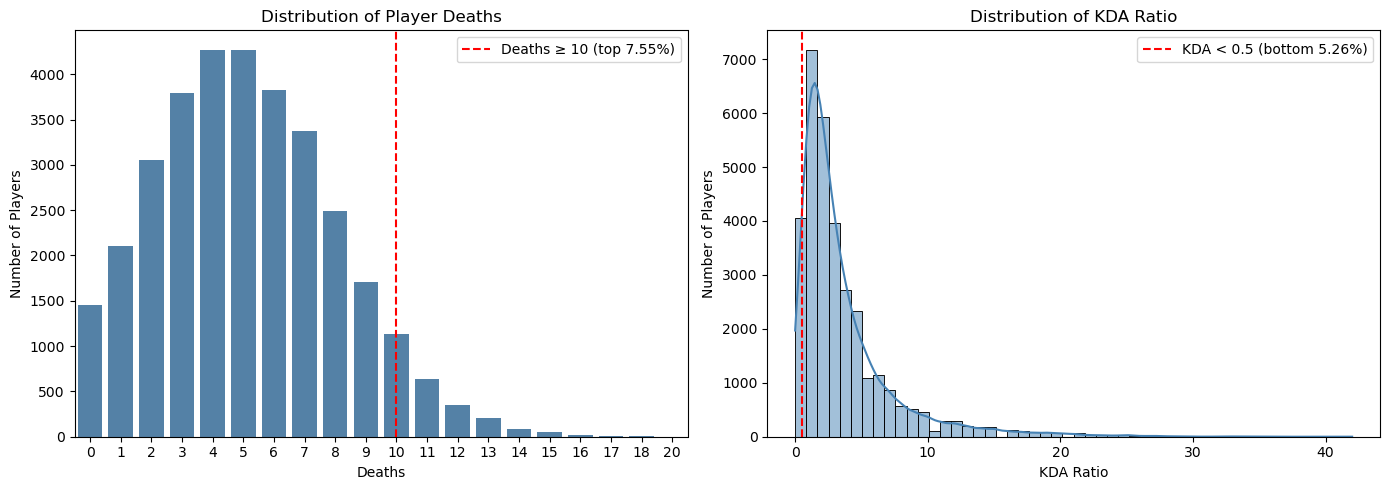

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Percentile
death_threshold = 10
death_percentile = (
    (df_full_clean['DEATHS_player'] >= death_threshold)
    .mean() * 100
)

kda_threshold = 0.5
kda_percentile = (
    (df_full_clean['KDA RATIO_player'] < kda_threshold)
    .mean() * 100
)

# Subplots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Deaths distribution 
sns.countplot(
    x='DEATHS_player',
    data=df_full_clean,
    color='steelblue',
    ax=axes[0]
)

axes[0].axvline(
    death_threshold,
    linestyle='--',
    color='red',
    label=f'Deaths ≥ {death_threshold} (top {death_percentile:.2f}%)'
)

axes[0].set_xlabel('Deaths')
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Distribution of Player Deaths')
axes[0].legend()

# Right: KDA distribution 
sns.histplot(
    df_full_clean['KDA RATIO_player'],
    bins=50,
    color='steelblue',
    kde=True,
    ax=axes[1]
)

axes[1].axvline(
    kda_threshold,
    linestyle='--',
    color='red',
    label=f'KDA < {kda_threshold} (bottom {kda_percentile:.2f}%)'
)

axes[1].set_xlabel('KDA Ratio')
axes[1].set_ylabel('Number of Players')
axes[1].set_title('Distribution of KDA Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

The distribution of player deaths is right-skewed, with the majority of players recording between 2 and 7 deaths per match. A **clear right-tail emerges beyond 10 deaths**, representing approximately the top 7.55% of observations. This region corresponds to **atypically high death counts and is unlikely to reflect standard gameplay patterns.**

The KDA ratio distribution is highly right-skewed, with most players exhibiting values well above 1. **KDA values below 0.5 fall within the bottom 5.26%, reflecting minimal kill or assist contribution relative to deaths**

**Use of joint criteria of Deaths and KDA:**

However, high death counts alone may occur for tanks or frontline initiators who intentionally absorb damage to enable team fights. Similarly, low KDA ratios may arise in early-terminated matches or in low-participation scenarios without implying repeated feeding.

By combining both conditions, we can better capture players who not only die frequently but also fail to contribute meaningfully to kills or assists, aligning with the typical definition of feeding behavior.

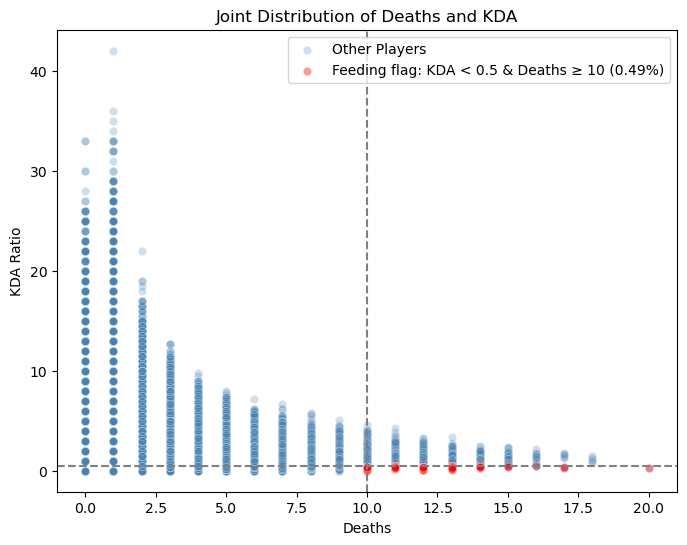

In [ ]:
plt.figure(figsize=(8, 6))

# Highlight points where KDA < 0.5 and Deaths >= 10
highlight = (
    (df_full_clean['KDA RATIO_player'] < 0.5) &
    (df_full_clean['DEATHS_player'] >= 10)
)
highlight_pct = highlight.mean() * 100

sns.scatterplot(
    data=df_full_clean,
    x='DEATHS_player',
    y='KDA RATIO_player',
    alpha=0.25,
    color='steelblue',
    label='Other Players'
)

sns.scatterplot(
    data=df_full_clean[highlight],
    x='DEATHS_player',
    y='KDA RATIO_player',
    alpha=0.4,
    color='red',
    label=f'Feeding flag: KDA < 0.5 & Deaths ≥ 10 ({highlight_pct:.2f}%)'

)

plt.axvline(10, linestyle='--', color='grey')
plt.axhline(0.5, linestyle='--', color='grey')

plt.xlabel('Deaths')
plt.ylabel('KDA Ratio')
plt.title('Joint Distribution of Deaths and KDA')
plt.legend()
plt.show()

This figure shows the joint distribution of player deaths and KDA ratio, with the feeding flag highlighted. While high-death players span a wide range of KDA values and low-KDA players appear across multiple death counts. However, their intersection isolates a small, well-separated group of players characterized by repeated deaths and negligible contribution. Based on this observation, we **define the feeding flag as players with deaths ≥ 10 and KDA < 0.5**, which serves as a **selective and behaviorally grounded proxy for feeding.**

**<span style="color:red;">(seems like it makes more sense to add creating 'FLAG' variable after this part!!!)</span>**

### 5.4: Add proxy labels

In [122]:
df_full_clean.insert(0,'PROXY TOXIC LABEL', (df_full_clean['EARLY SURRENDER_player']==True) | (df_full_clean['FLAG']==True) | (df_full_clean['TROLL BUILD (15 MIN)_player']==True))

In [123]:
df_full_clean['PROXY TOXIC LABEL'].sum()

np.int64(739)

In [127]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32812 entries, 0 to 33339
Data columns (total 70 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROXY TOXIC LABEL                     32812 non-null  bool   
 1   TEAM                                  32812 non-null  int64  
 2   matchId_player                        32812 non-null  object 
 3   WIN_player                            32812 non-null  bool   
 4   CHAMPION NAME_player                  32812 non-null  object 
 5   EARLY SURRENDER_player                32812 non-null  bool   
 6   SURRENDER_player                      32812 non-null  bool   
 7   SURRENDER TIME (MIN)_player           12322 non-null  float64
 8   GAME DURATION_player                  32812 non-null  int64  
 9   TROLL BUILD (15 MIN)_player           32812 non-null  bool   
 10  FLAG                                  32812 non-null  bool   
 11  KDA RATIO_player    

In [126]:
df_full_clean 

,PROXY TOXIC LABEL,TEAM,matchId_player,WIN_player,CHAMPION NAME_player,EARLY SURRENDER_player,SURRENDER_player,SURRENDER TIME (MIN)_player,GAME DURATION_player,TROLL BUILD (15 MIN)_player,FLAG,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,firstBloodKill_player,items_15min_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,tags_championOverall,partype_championOverall,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,False,1,NA1_5269865992,True,Yasuo,False,True,23.333333,1400,False,False,7.000000,5.760000,1,6.666667,0.514286,9,1,9.857143,467.828571,0.333333,0.147033,2,10,4,3,TOP,top,12816,14985,10916,225,5,12,0,False,"1055,2031,3006,3363,3153,1018",11.0,6539.0,136.0,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0,"['Fighter', 'Assassin']",Flow,8,4,4,590.0,110.0,100.0,0.0,345.0,32.0,4.60,32.0,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,False,1,NA1_5269865992,True,Nasus,False,True,23.333333,1400,False,False,12.000000,10.080000,1,6.666667,0.642857,8,1,7.800000,397.671429,0.571429,0.233012,0,6,5,7,MIDDLE,middle,20310,21173,9279,180,2,15,0,False,"1056,3009,2031,3078,3363",10.0,5639.0,118.0,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0,"['Fighter', 'Tank']",Mana,7,5,6,631.0,104.0,326.0,62.0,350.0,34.0,4.70,32.0,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,False,1,NA1_5269865992,True,Sylas,False,True,23.333333,1400,False,False,16.000000,13.190000,1,6.666667,0.728571,4,1,7.285714,433.628571,0.761905,0.212927,1,5,5,11,JUNGLE,jungle,18560,30340,10118,11,159,17,0,False,"1102,1082,3364,6653,1052,2022",10.0,5792.0,104.0,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0,"['Mage', 'Assassin']",Mana,3,4,8,600.0,122.0,400.0,70.0,340.0,29.0,5.20,32.0,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,False,1,NA1_5269865992,True,Draven,False,True,23.333333,1400,False,False,1.571429,-0.468571,7,46.666667,0.300000,7,0,7.842857,381.557143,0.523810,0.162800,1,8,1,10,BOTTOM,bottom,14190,14449,8903,175,8,7,0,False,"1055,1001,3072,1042,1042,3363",9.0,5170.0,129.0,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0,['Marksman'],Mana,9,3,1,675.0,104.0,361.0,39.0,330.0,29.0,4.50,30.0,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,False,1,NA1_5269865992,True,Swain,False,True,23.333333,1400,False,False,3.600000,2.590000,5,33.333333,2.400000,24,4,1.414286,359.485714,0.857143,0.244229,0,8,6,12,UTILITY,support,21288,26427,8388,33,0,56,0,False,"3070,3364,3116,1001,2031,2055",8.0,5228.0,19.0,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0,"['Mage', 'Support']",Mana,2,6,9,595.0,99.0,400.0,29.0,330.0,25.0,4.70,31.0,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [ ]:
# # Save to CSV for analysis
# df_full_clean.to_csv("final_cleaned_data_with_proxy_labels_v3.csv", index=False)
# print("Saved file: final_cleaned_data_with_proxy_labels_v3.csv")

Saved file: final_cleaned_data_with_proxy_labels_v3.csv


## Section 6: Data Analysis with Visualisation

In [129]:
# Load data set from csv first
df_full_clean = pd.read_csv('final_cleaned_data_with_proxy_labels_v3.csv')

In [130]:
df_full_clean

,PROXY TOXIC LABEL,TEAM,matchId_player,WIN_player,CHAMPION NAME_player,EARLY SURRENDER_player,SURRENDER_player,SURRENDER TIME (MIN)_player,GAME DURATION_player,TROLL BUILD (15 MIN)_player,FLAG,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,firstBloodKill_player,items_15min_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,tags_championOverall,partype_championOverall,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,False,1,NA1_5269865992,True,Yasuo,False,True,23.333333,1400,False,False,7.000000,5.760000,1,6.666667,0.514286,9,1,9.857143,467.828571,0.333333,0.147033,2,10,4,3,TOP,top,12816,14985,10916,225,5,12,0,False,"1055,2031,3006,3363,3153,1018",11.0,6539.0,136.0,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0,"['Fighter', 'Assassin']",Flow,8,4,4,590.0,110.0,100.0,0.0,345.0,32.0,4.60,32.0,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,False,1,NA1_5269865992,True,Nasus,False,True,23.333333,1400,False,False,12.000000,10.080000,1,6.666667,0.642857,8,1,7.800000,397.671429,0.571429,0.233012,0,6,5,7,MIDDLE,middle,20310,21173,9279,180,2,15,0,False,"1056,3009,2031,3078,3363",10.0,5639.0,118.0,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0,"['Fighter', 'Tank']",Mana,7,5,6,631.0,104.0,326.0,62.0,350.0,34.0,4.70,32.0,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,False,1,NA1_5269865992,True,Sylas,False,True,23.333333,1400,False,False,16.000000,13.190000,1,6.666667,0.728571,4,1,7.285714,433.628571,0.761905,0.212927,1,5,5,11,JUNGLE,jungle,18560,30340,10118,11,159,17,0,False,"1102,1082,3364,6653,1052,2022",10.0,5792.0,104.0,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0,"['Mage', 'Assassin']",Mana,3,4,8,600.0,122.0,400.0,70.0,340.0,29.0,5.20,32.0,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,False,1,NA1_5269865992,True,Draven,False,True,23.333333,1400,False,False,1.571429,-0.468571,7,46.666667,0.300000,7,0,7.842857,381.557143,0.523810,0.162800,1,8,1,10,BOTTOM,bottom,14190,14449,8903,175,8,7,0,False,"1055,1001,3072,1042,1042,3363",9.0,5170.0,129.0,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0,['Marksman'],Mana,9,3,1,675.0,104.0,361.0,39.0,330.0,29.0,4.50,30.0,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,False,1,NA1_5269865992,True,Swain,False,True,23.333333,1400,False,False,3.600000,2.590000,5,33.333333,2.400000,24,4,1.414286,359.485714,0.857143,0.244229,0,8,6,12,UTILITY,support,21288,26427,8388,33,0,56,0,False,"3070,3364,3116,1001,2031,2055",8.0,5228.0,19.0,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0,"['Mage', 'Support']",Mana,2,6,9,595.0,99.0,400.0,29.0,330.0,25.0,4.70,31.0,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [131]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32812 entries, 0 to 32811
Data columns (total 70 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROXY TOXIC LABEL                     32812 non-null  bool   
 1   TEAM                                  32812 non-null  int64  
 2   matchId_player                        32812 non-null  object 
 3   WIN_player                            32812 non-null  bool   
 4   CHAMPION NAME_player                  32812 non-null  object 
 5   EARLY SURRENDER_player                32812 non-null  bool   
 6   SURRENDER_player                      32812 non-null  bool   
 7   SURRENDER TIME (MIN)_player           12322 non-null  float64
 8   GAME DURATION_player                  32812 non-null  int64  
 9   TROLL BUILD (15 MIN)_player           32812 non-null  bool   
 10  FLAG                                  32812 non-null  bool   
 11  KDA RATIO_playe

In [132]:
df_full_clean.describe()

,TEAM,SURRENDER TIME (MIN)_player,GAME DURATION_player,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
count,32812.000000,12322.000000,32812.000000,32812.000000,32811.000000,32812.000000,32414.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.00000,32812.000000,32812.000000,32812.000000,32156.000000,32156.000000,32156.000000,32812.000000,32811.000000,32812.000000,32812.000000,32615.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000,32812.000000
mean,3337.225680,21.634102,1601.990156,3.644223,0.994188,5.100512,20.315296,1.060914,12.672528,3.803883,5.942129,390.619909,0.490492,0.199979,1.038065,5.777216,5.092923,7.774290,18911.413202,24653.836036,10509.019231,126.47440,33.232842,29.559582,0.137937,9.459603,5470.177354,92.581664,185.855419,2.650116,50.352285,5.763526,5.539356,169.337543,11437.222449,5.719859,4.284103,5.034561,618.573662,104.831830,437.877484,36.594889,335.165062,29.450414,4.578124,30.744514,1.664394,341.898696,6.273353,0.660379,9.415791,0.589711,58.793155,3.140843,2.559181,0.650257
std,1923.494964,7.340467,423.420817,3.817555,3.764087,2.924364,9.439354,0.812146,12.093499,3.610535,2.768241,82.935595,0.178253,0.080349,1.332794,2.220575,4.062530,5.840802,11477.799048,12664.213654,3684.858324,93.13814,63.423624,25.718674,0.402050,1.289752,1029.621856,40.547391,129.081343,0.637894,8.633861,3.555403,8.035971,72.861150,1942.329245,2.876460,2.039636,2.804158,34.119413,8.212687,1055.863680,19.903300,7.227592,5.614071,0.521792,1.621843,0.380692,194.603438,1.925985,0.142524,10.260395,0.308240,5.288366,0.648503,0.860276,0.028966
min,1.000000,1.666667,100.000000,0.000000,-15.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163.278689,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,501.000000,0.00000,0.000000,0.000000,0.000000,4.000000,2568.000000,0.000000,1.000000,0.250000,0.000000,0.310000,0.010000,15.630000,2701.000000,0.000000,0.000000,0.000000,410.000000,69.000000,0.000000,0.000000,315.000000,18.000000,0.000000,22.000000,1.100000,125.000000,0.000000,0.000000,0.000000,0.000000,44.000000,0.000000,0.000000,0.475000
25%,1674.000000,16.033333,1375.000000,1.333333,-1.220000,3.000000,14.705882,0.552968,6.000000,1.000000,5.322322,329.376110,0.379310,0.145167,0.000000,5.000000,2.000000,3.000000,10113.750000,15832.000000,7924.750000,27.00000,0.000000,14.000000,0.000000,9.000000,4740.000000,84.000000,80.000000,2.250000,46.728

### 6.1: smth

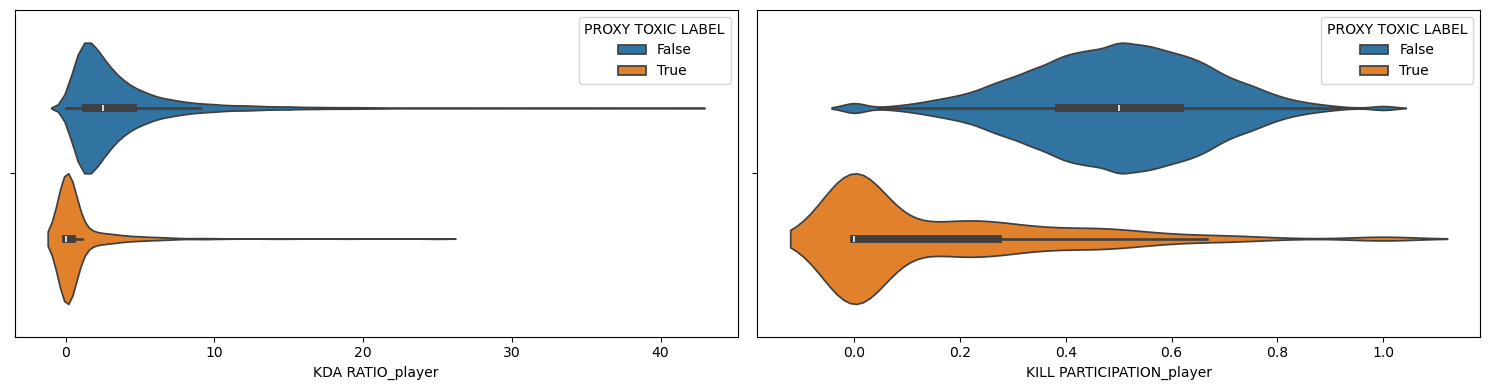

In [166]:
# Toxic players contribute less to the team 
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.violinplot(data=df_full_clean, x='KDA RATIO_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[0])
sns.violinplot(data=df_full_clean, x='KILL PARTICIPATION_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[1])

plt.tight_layout()

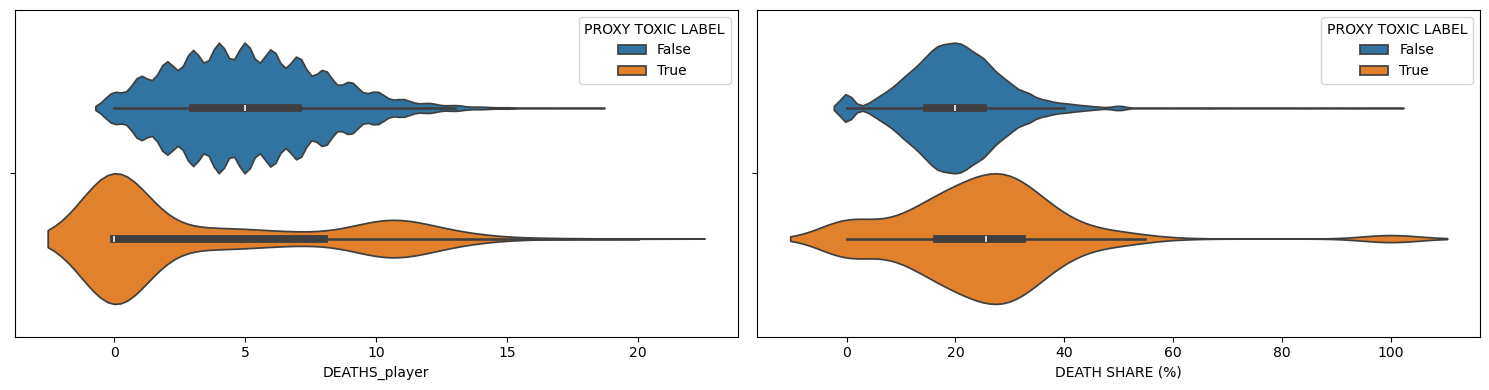

In [167]:
# Toxic players do die more, which makes their team worse
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.violinplot(data=df_full_clean, x='DEATHS_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[0])
sns.violinplot(data=df_full_clean, x='DEATH SHARE (%)', hue='PROXY TOXIC LABEL', fill=True, ax=axes[1])

plt.tight_layout()

<Axes: xlabel='SURRENDER TIME (MIN)_player'>

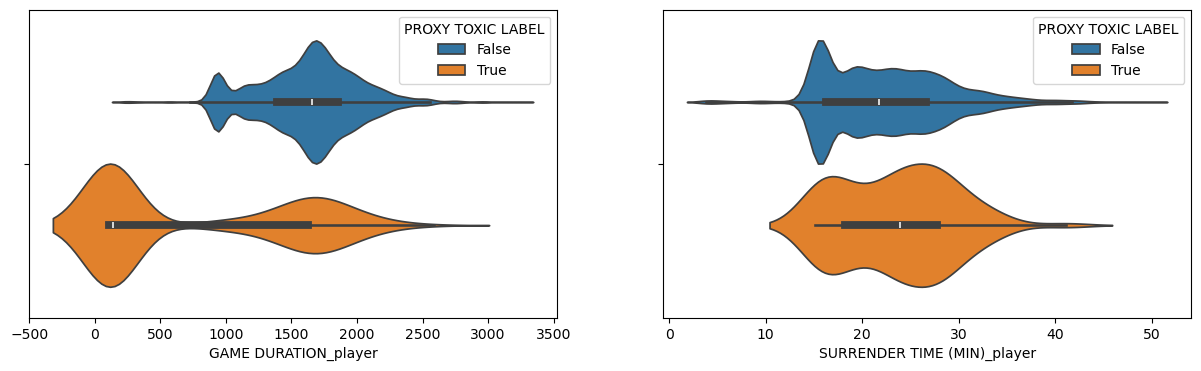

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.violinplot(data=df_full_clean, x='GAME DURATION_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[0])
sns.violinplot(data=df_full_clean[df_full_clean['SURRENDER_player']], x='SURRENDER TIME (MIN)_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[1])
# of those who did surrender, split it by toxic and non-toxic
plt.tight_layout()


### champion analysis

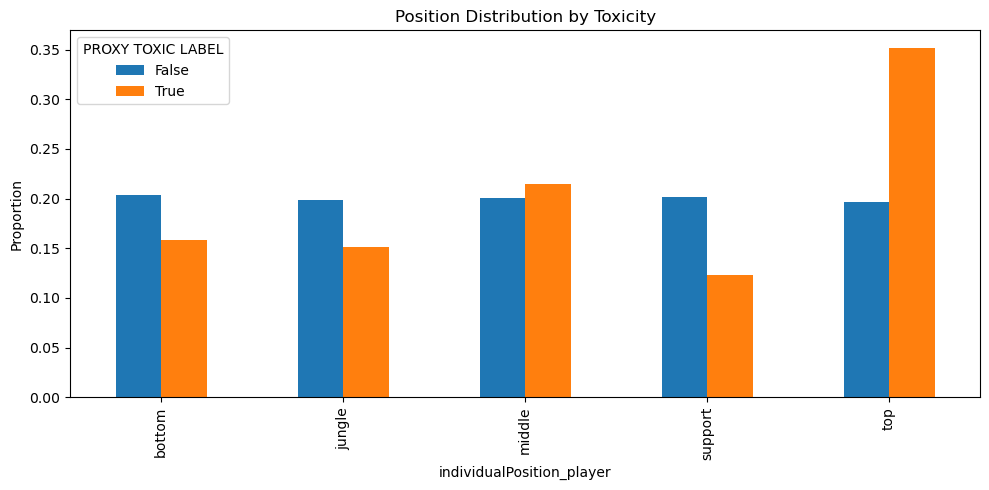

In [ ]:
# Toxic behavior by position: top is most toxic 
# SHOULD CALCULATE TOXICITY RATE OF EACH POSITION TOO !!!! !!!!!
ct = pd.crosstab(df_full_clean['individualPosition_player'], 
                 df_full_clean['PROXY TOXIC LABEL'], 
                 normalize='columns')

ax = ct.plot(kind='bar', figsize=(10, 5))
ax.set_title('Position Distribution by Toxicity')
ax.set_ylabel('Proportion')

plt.tight_layout()

In [ ]:
df_surrendered = df_full_clean[df_full_clean['SURRENDER_player'] == True]

avg_surrender_time_by_position = df_full_clean.pivot_table(
    values='SURRENDER TIME (MIN)_player',
    index='individualPosition_player',
    columns='PROXY TOXIC LABEL',
    aggfunc='mean'
)

avg_surrender_time_by_position_surrenderedTeams = df_surrendered.pivot_table(
    values='SURRENDER TIME (MIN)_player',
    index='individualPosition_player',
    columns='PROXY TOXIC LABEL',
    aggfunc='mean'
)

game_duration_by_position = df_full_clean.pivot_table(
    values='GAME DURATION_player',
    index='individualPosition_player',
    columns='PROXY TOXIC LABEL',
    aggfunc='mean'
)

In [207]:
df_full_clean

,PROXY TOXIC LABEL,TEAM,matchId_player,WIN_player,CHAMPION NAME_player,EARLY SURRENDER_player,SURRENDER_player,SURRENDER TIME (MIN)_player,GAME DURATION_player,TROLL BUILD (15 MIN)_player,FLAG,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,firstBloodKill_player,items_15min_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,tags_championOverall,partype_championOverall,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,False,1,NA1_5269865992,True,Yasuo,False,True,23.333333,1400,False,False,7.000000,5.760000,1,6.666667,0.514286,9,1,9.857143,467.828571,0.333333,0.147033,2,10,4,3,TOP,top,12816,14985,10916,225,5,12,0,False,"1055,2031,3006,3363,3153,1018",11.0,6539.0,136.0,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0,"['Fighter', 'Assassin']",Flow,8,4,4,590.0,110.0,100.0,0.0,345.0,32.0,4.60,32.0,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,False,1,NA1_5269865992,True,Nasus,False,True,23.333333,1400,False,False,12.000000,10.080000,1,6.666667,0.642857,8,1,7.800000,397.671429,0.571429,0.233012,0,6,5,7,MIDDLE,middle,20310,21173,9279,180,2,15,0,False,"1056,3009,2031,3078,3363",10.0,5639.0,118.0,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0,"['Fighter', 'Tank']",Mana,7,5,6,631.0,104.0,326.0,62.0,350.0,34.0,4.70,32.0,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,False,1,NA1_5269865992,True,Sylas,False,True,23.333333,1400,False,False,16.000000,13.190000,1,6.666667,0.728571,4,1,7.285714,433.628571,0.761905,0.212927,1,5,5,11,JUNGLE,jungle,18560,30340,10118,11,159,17,0,False,"1102,1082,3364,6653,1052,2022",10.0,5792.0,104.0,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0,"['Mage', 'Assassin']",Mana,3,4,8,600.0,122.0,400.0,70.0,340.0,29.0,5.20,32.0,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,False,1,NA1_5269865992,True,Draven,False,True,23.333333,1400,False,False,1.571429,-0.468571,7,46.666667,0.300000,7,0,7.842857,381.557143,0.523810,0.162800,1,8,1,10,BOTTOM,bottom,14190,14449,8903,175,8,7,0,False,"1055,1001,3072,1042,1042,3363",9.0,5170.0,129.0,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0,['Marksman'],Mana,9,3,1,675.0,104.0,361.0,39.0,330.0,29.0,4.50,30.0,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,False,1,NA1_5269865992,True,Swain,False,True,23.333333,1400,False,False,3.600000,2.590000,5,33.333333,2.400000,24,4,1.414286,359.485714,0.857143,0.244229,0,8,6,12,UTILITY,support,21288,26427,8388,33,0,56,0,False,"3070,3364,3116,1001,2031,2055",8.0,5228.0,19.0,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0,"['Mage', 'Support']",Mana,2,6,9,595.0,99.0,400.0,29.0,330.0,25.0,4.70,31.0,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Text(0.5, 1.02, 'Feature Relationships by Toxicity')

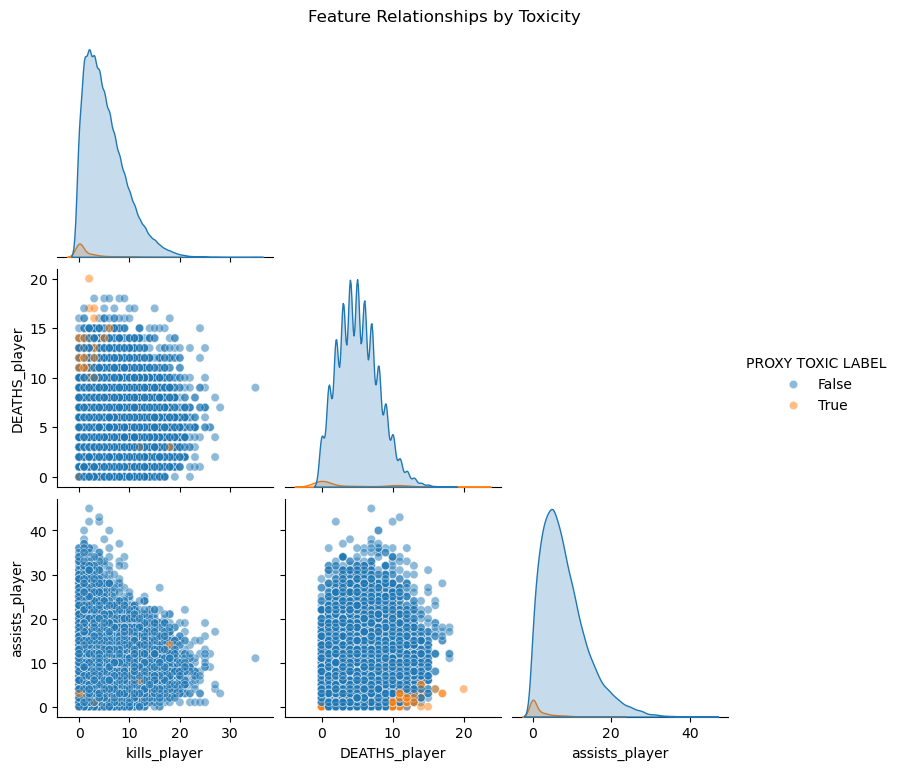

In [210]:
# Pairplot of key metrics colored by toxicity
key_features = ['PROXY TOXIC LABEL', 
    'kills_player', 'DEATHS_player', 'assists_player'
]

sns.pairplot(df_full_clean[key_features], hue='PROXY TOXIC LABEL', corner=True, 
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Feature Relationships by Toxicity', y=1.02)

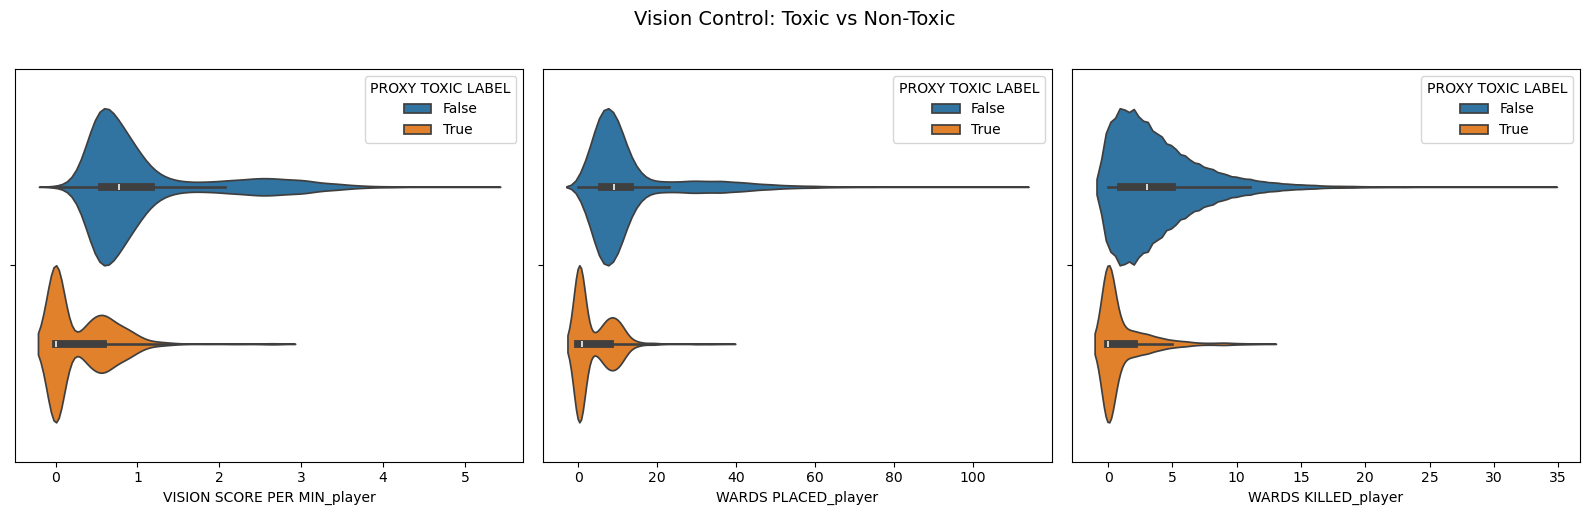

In [ ]:
# Vision metrics often differ between toxic/non-toxic
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.violinplot(data=df_full_clean, x='VISION SCORE PER MIN_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[0])
sns.violinplot(data=df_full_clean, x='WARDS PLACED_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[1])
sns.violinplot(data=df_full_clean, x='WARDS KILLED_player', hue='PROXY TOXIC LABEL', fill=True, ax=axes[2])

plt.suptitle('Vision Control: Toxic vs Non-Toxic', fontsize=14, y=1.02)
plt.tight_layout()

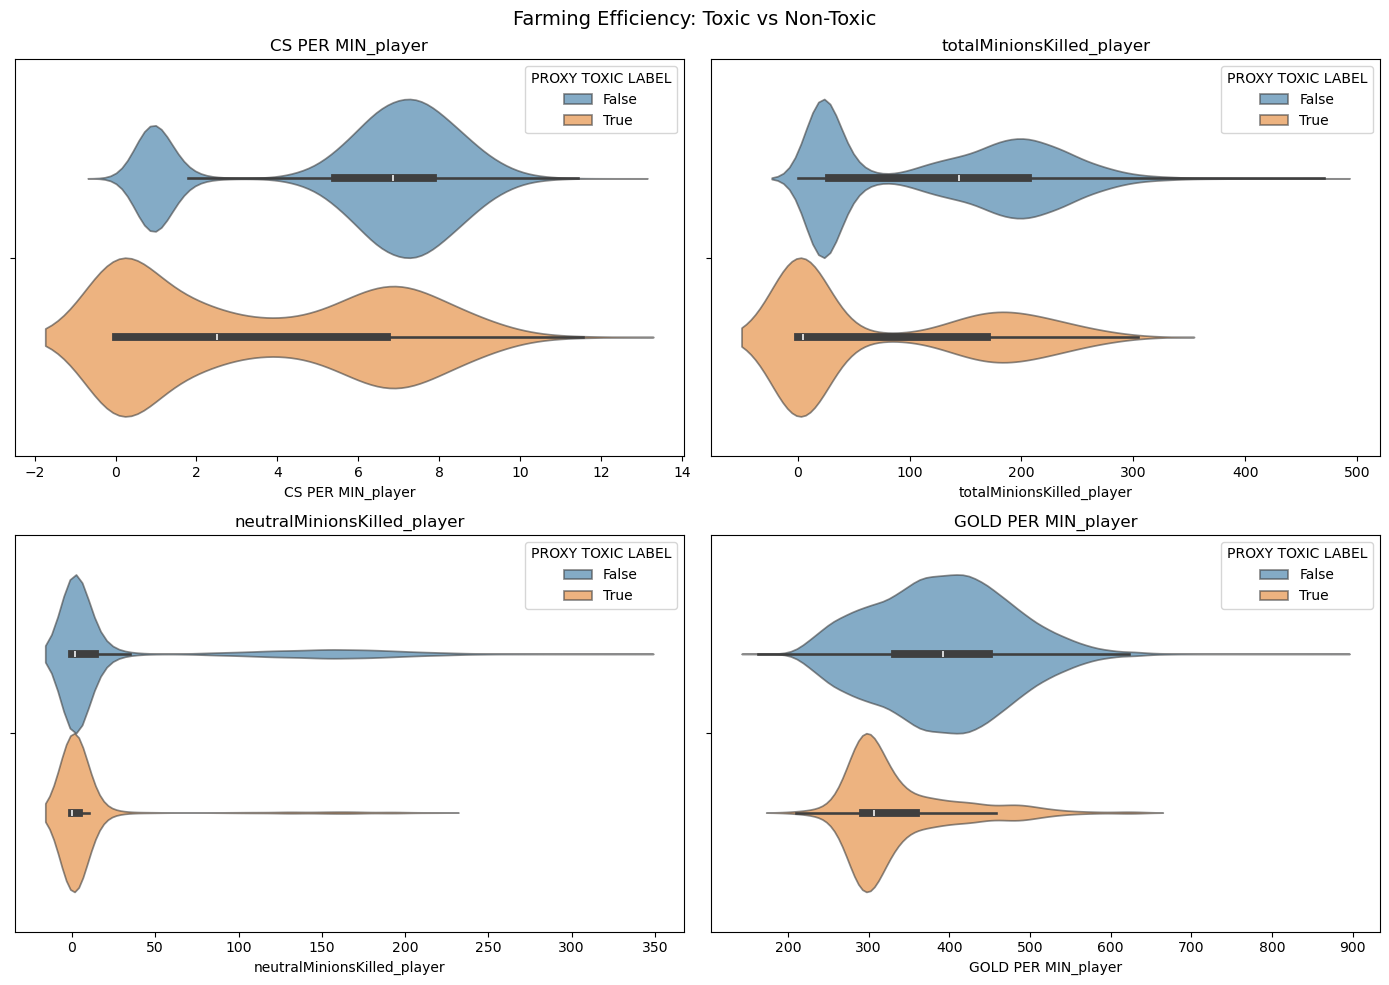

In [ ]:
# CS and farming patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

farm_metrics = [
    'CS PER MIN_player',
    'totalMinionsKilled_player',
    'neutralMinionsKilled_player',
    'GOLD PER MIN_player'
]
# try show kdeplot
for ax, metric in zip(axes.flat, farm_metrics):
    sns.violinplot(data=df_full_clean, x=metric, hue='PROXY TOXIC LABEL',
                fill=True, common_norm=False, alpha=0.6, ax=ax)
    ax.set_title(metric)

plt.suptitle('Farming Efficiency: Toxic vs Non-Toxic', fontsize=14)
plt.tight_layout()


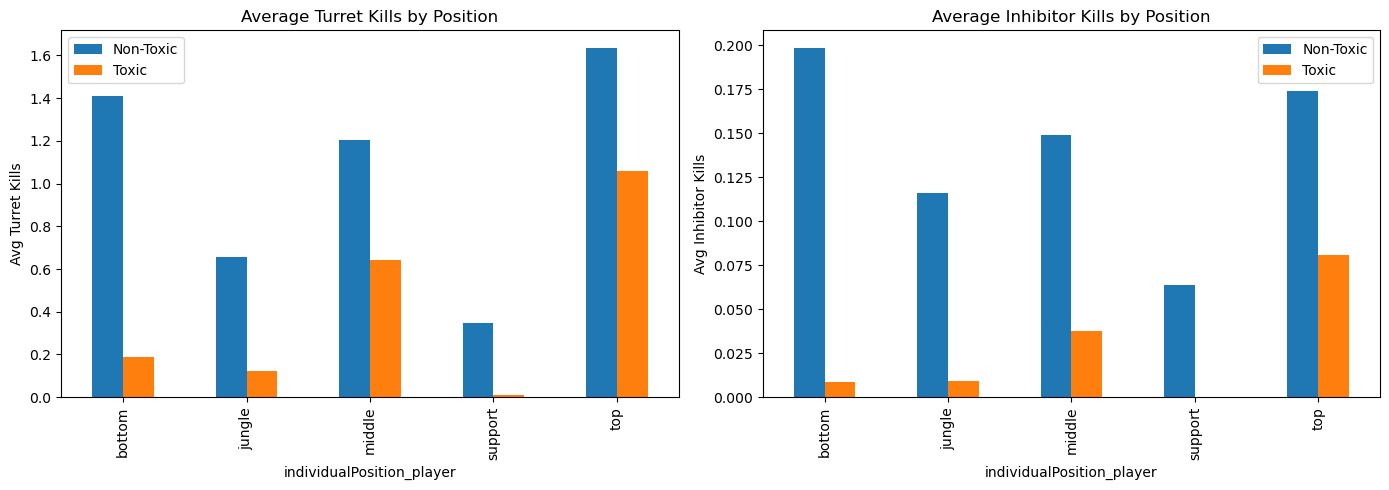

In [219]:
# Turret kills by position and toxicity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Turrets
turret_pivot = df_full_clean.pivot_table(
    values='TURRET KILLS_player',
    index='individualPosition_player',
    columns='PROXY TOXIC LABEL',
    aggfunc='mean'
)
turret_pivot.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Turret Kills by Position')
axes[0].set_ylabel('Avg Turret Kills')
axes[0].legend(['Non-Toxic', 'Toxic'])

# Inhibitors
inhib_pivot = df_full_clean.pivot_table(
    values='inhibitorKills_player',
    index='individualPosition_player',
    columns='PROXY TOXIC LABEL',
    aggfunc='mean'
)
inhib_pivot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Inhibitor Kills by Position')
axes[1].set_ylabel('Avg Inhibitor Kills')
axes[1].legend(['Non-Toxic', 'Toxic'])

plt.tight_layout()


### 6.2 added some analysis - zoey

#### Correlation between game outcome and proxy-toxic behavior

In [ ]:
tox_by_win = (
    df_full_clean.groupby('WIN_player')['PROXY TOXIC LABEL']
      .agg(rate='mean', count='size')
      .reset_index()
)

tox_by_win['rate_pct'] = tox_by_win['rate'] * 100
tox_by_win

,WIN_player,rate,count,rate_pct
0,False,0.025862,16356,2.586207
1,True,0.019203,16456,1.920272


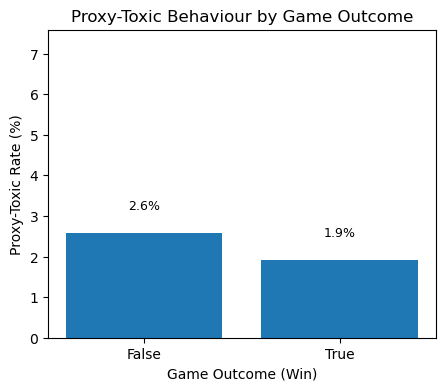

In [ ]:
plt.figure(figsize=(5,4))

plt.bar(
    tox_by_win['WIN_player'].astype(str),
    tox_by_win['rate_pct']
)

plt.xlabel('Game Outcome (Win)')
plt.ylabel('Proxy-Toxic Rate (%)')
plt.title('Proxy-Toxic Behaviour by Game Outcome')

for idx, row in tox_by_win.iterrows():
    plt.text(
        str(row['WIN_player']),
        row['rate_pct'] + 0.5,
        f"{row['rate_pct']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(0, tox_by_win['rate_pct'].max() + 5)
plt.show()

Proxy-toxic behavior is slightly higher in losses (2.6%) than wins (1.9%)

- suggests a link between losing and toxic behavior
- Proxy-toxic behavior may contribute to or result from losing states

In [ ]:
# Convert booleans to 0/1 for analysis clarity
df_full_clean['win_bin'] = df_full_clean['WIN_player'].astype(int)
df_full_clean['toxic_bin'] = df_full_clean['PROXY TOXIC LABEL'].astype(int)

# Build a 2x2 contingency table:
# rows = win (0/1), cols = toxic (0/1)
ct = pd.crosstab(df_full_clean['win_bin'], df_full_clean['toxic_bin'])
ct.index = ['Loss (0)', 'Win (1)']
ct.columns = ['Normal (0)', 'Proxy-Toxic (1)']

ct

,Normal (0),Proxy-Toxic (1)
Loss (0),15933,423
Win (1),16140,316


In [ ]:
# Compute Phi coefficient from the contingency table
a = ct.loc['Win (1)', 'Proxy-Toxic (1)']     # win & toxic
b = ct.loc['Win (1)', 'Normal (0)']         # win & normal
c = ct.loc['Loss (0)', 'Proxy-Toxic (1)']   # loss & toxic
d = ct.loc['Loss (0)', 'Normal (0)']        # loss & normal

phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))

print(f"Phi correlation (WIN vs PROXY_TOXIC): {phi:.4f}")

Phi correlation (WIN vs PROXY_TOXIC): -0.0224


#### Proxy-toxic behaviour by roles

In [ ]:
# Use standardized team positions
role_col = 'teamPosition_player'
valid_roles = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY']

df_role = df_full_clean[df_full_clean[role_col].isin(valid_roles)].copy()

# Calculate proxy-toxic rate by role
tox_by_role = (
    df_role
    .groupby(role_col)['PROXY TOXIC LABEL']
    .agg(
        toxic_rate='mean',
        player_count='size'
    )
    .reset_index()
    .sort_values('toxic_rate', ascending=False)
)

tox_by_role['toxic_rate_pct'] = tox_by_role['toxic_rate'] * 100
tox_by_role

,teamPosition_player,toxic_rate,player_count,toxic_rate_pct
3,TOP,0.039683,6552,3.968254
2,MIDDLE,0.024116,6593,2.411649
0,BOTTOM,0.017642,6632,1.764174
1,JUNGLE,0.017324,6465,1.732405
4,UTILITY,0.013851,6570,1.385084


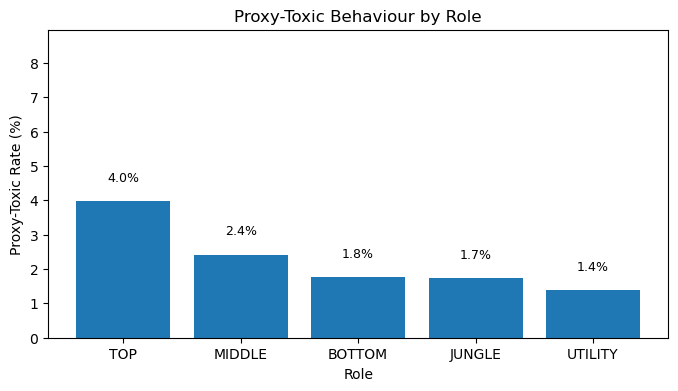

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(
    tox_by_role[role_col],
    tox_by_role['toxic_rate_pct']
)

plt.ylabel('Proxy-Toxic Rate (%)')
plt.xlabel('Role')
plt.title('Proxy-Toxic Behaviour by Role')

# Annotate bars with percentage values
for idx, row in tox_by_role.iterrows():
    plt.text(
        row[role_col],
        row['toxic_rate_pct'] + 0.5,
        f"{row['toxic_rate_pct']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(0, tox_by_role['toxic_rate_pct'].max() + 5)
plt.show()

- Top lane players are most likely to exhibit proxy-toxic behaviour, while Support players are least likely

=> This pattern likely reflects role-specific gameplay characteristics: 
- Top lane is highly isolated with limited opportunities for recovery once behind,
- whereas Support players are more integrated into team play and face less individual performance pressure.

#### Correlation analysis with proxy toxic behaviour

In [ ]:

# Select main variables for correlation analysis
corr_features = [
    'toxic_bin',
    'win_bin',
    'KDA RATIO_player',
    'KDA DELTA',
    'DEATH SHARE (%)',
    'VISION SCORE PER MIN_player',
    'WARDS PLACED_player',
    'WARDS KILLED_player',
    'CS PER MIN_player',
    'GOLD PER MIN_player',
    'KILL PARTICIPATION_player',
    'TEAM DAMAGE (%)_player',
    'assists_player'
]

corr_df = df_full_clean[corr_features].copy()

# Compute Spearman correlation matrix
corr_matrix = corr_df.corr(method='spearman')

corr_matrix

,toxic_bin,win_bin,KDA RATIO_player,KDA DELTA,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,assists_player
toxic_bin,1.000000,-0.022441,-0.194119,-0.173023,0.045654,-0.175771,-0.154426,-0.153385,-0.114534,-0.110862,-0.193961,-0.030566,-0.186549
win_bin,-0.022441,1.000000,0.639293,0.647709,-0.032689,0.066054,0.027446,0.057839,0.133172,0.381283,0.048136,-0.003617,0.336214
KDA RATIO_player,-0.194119,0.639293,1.000000,0.942969,-0.476354,0.246936,0.127987,0.222994,0.140817,0.451136,0.479587,0.091644,0.549339
KDA DELTA,-0.173023,0.647709,0.942969,1.000000,-0.452485,0.148962,0.106330,0.150545,0.235650,0.503625,0.371254,0.173342,0.460248
DEATH SHARE (%),0.045654,-0.032689,-0.476354,-0.452485,1.000000,-0.020855,0.055390,-0.010428,-0.230933,-0.186217,-0.097103,-0.060503,-0.006672
VISION SCORE PER MIN_player,-0.175771,0.066054,0.246936,0.148962,-0.020855,1.000000,0.645971,0.708782,-0.422242,-0.297098,0.382166,-0.390365,0.483085
WARDS PLACED_player,-0.154426,0.027446,0.127987,0.106330,0.055390,0.645971,1.000000,0.421655,-0.372193,-0.331292,0.230013,-0.311232,0.471035
WARDS KILLED_player,-0.153385,0.057839,0.222994,0.150545,-0.010428,0.708782,0.421655,1.000000,-0.234888,-0.109129,0.350682,-0.221464,0.489101
CS PER MIN_player,-0.114534,0.133172,0.140817,0.235650,-0.230933,-0.422242,-0.372193,-0.234888,1.000000,0.727129,-0.213739,0.564112,-0.325469
GOLD PER MIN_player,-0.110862,0.381283,0.451136,0.503625,-0.186217,-0.297098,-0.331292,-0.109129,0.727129,1.000000,0.118439,0.640774,-0.026725


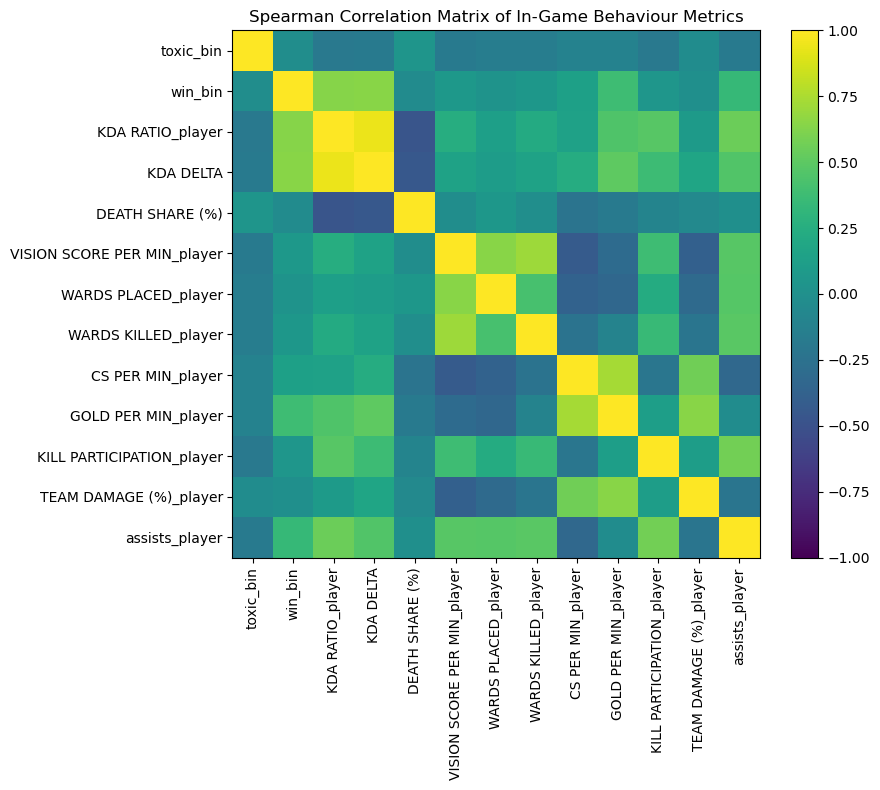

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
im = plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title('Spearman Correlation Matrix of In-Game Behaviour Metrics')

plt.tight_layout()
plt.show()

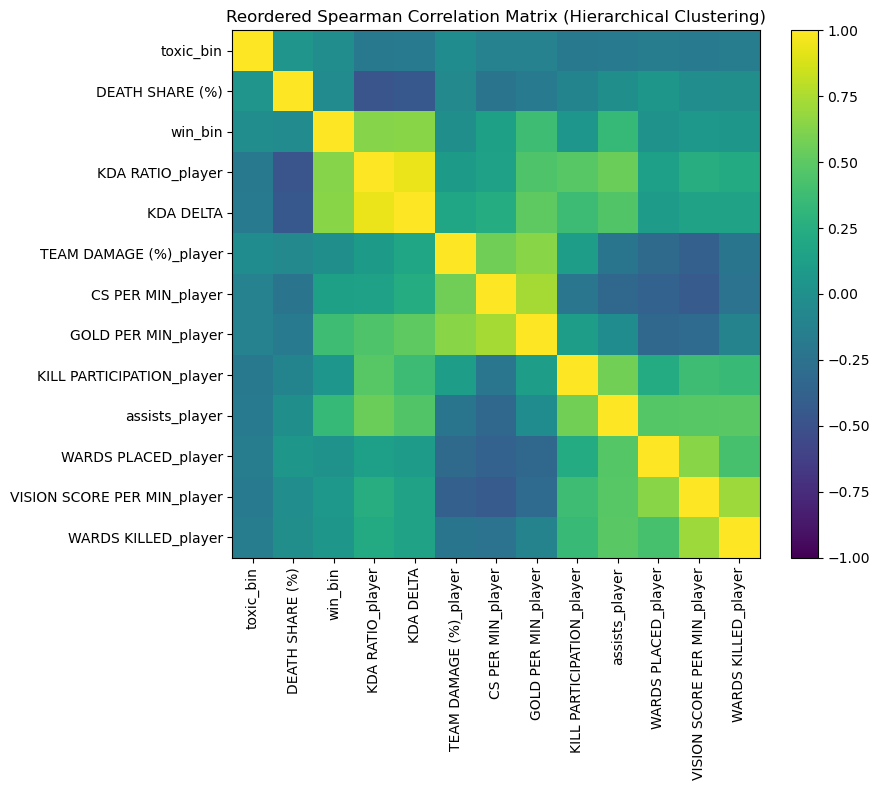

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# corr_matrix: Spearman correlation matrix (DataFrame)

# Convert correlation to distance
# Distance = 1 - |correlation|
distance_matrix = 1 - np.abs(corr_matrix)

# Condensed distance matrix for clustering
condensed_dist = squareform(distance_matrix.values, checks=False)

# Hierarchical clustering (average linkage)
linkage_matrix = linkage(condensed_dist, method='average')

# Get reordered indices
ordered_idx = leaves_list(linkage_matrix)

# Reorder correlation matrix
corr_reordered = corr_matrix.iloc[ordered_idx, ordered_idx]

# => Visuatlise reordered correlation matrix
plt.figure(figsize=(10,8))
im = plt.imshow(corr_reordered, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(
    range(len(corr_reordered.columns)),
    corr_reordered.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_reordered.index)),
    corr_reordered.index
)

plt.title('Reordered Spearman Correlation Matrix (Hierarchical Clustering)')
plt.tight_layout()
plt.show()

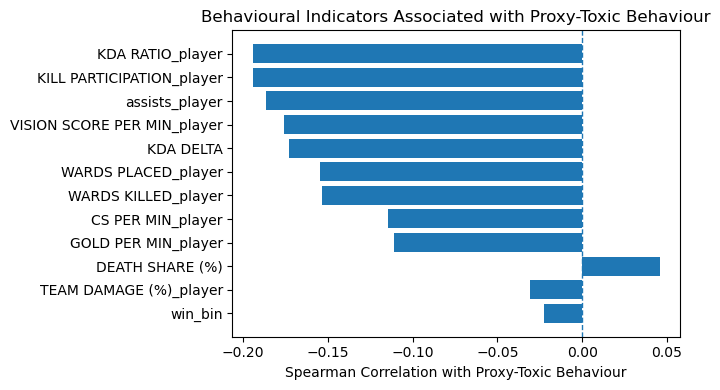

In [ ]:
# Prepare data (drop self-correlation)
plot_df = toxic_corr_ranked.copy()

# Reverse order for horizontal bar plot
plot_df = plot_df.iloc[::-1]

plt.figure(figsize=(7,4))
plt.barh(
    plot_df.index,
    plot_df['spearman_corr']
)

plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel('Spearman Correlation with Proxy-Toxic Behaviour')
plt.title('Behavioural Indicators Associated with Proxy-Toxic Behaviour')

plt.tight_layout()
plt.show()

Hierarchically reordered Spearman correlation matrix 
- clear grouping of in-game metrics into related behavior categories, such as performance (KDA ratio, KDA delta), economy (CS/min, gold/min), vision control (vision score/min, wards placed, wards killed), and team involvement (kill participation, assists)

Correlation with proxy-toxic behaviour:
- not strongly correlated with any single metric
- Proxy-toxic behaviour shows the negative correlations with combat performance (KDA ratio, KDA delta), team participation (kill participation, assists), and vision control metrics.
- Vision-related indicators exhibit consistent negative associations, suggesting early disengagement from map awareness and decision-making.
- Economic metrics (CS and gold per minute) show weaker correlations, indicating that toxicity is not primarily driven by farming inefficiency.

=> Overall, **proxy-toxic behaviour is characterised by coordinated declines across multiple gameplay dimensions** rather than isolated underperformance.

#### Proxy-toxic behavior by champions - by each champion name

In [ ]:
# Rename for clarity
df_full_clean['isToxic'] =df_full_clean['PROXY TOXIC LABEL']

champion_summary = (
   df_full_clean
    .groupby('CHAMPION NAME_player')
    .agg(
        toxicity_rate=('isToxic', 'mean'),
        n_games=('isToxic', 'size'),
        avg_kda=('KDA RATIO_player', 'mean'),
        avg_death_share=('DEATH SHARE (%)', 'mean'),
        difficulty=('CHAMPION DIFFICULTY_championOverall', 'first'),
        tags=('tags_championOverall', 'first')
    )
    .reset_index()
)

# Filter champions with sufficient sample size
champion_summary = champion_summary[champion_summary['n_games'] >= 50]

champion_summary['toxicity_rate_pct'] = champion_summary['toxicity_rate'] * 100

champion_summary.head()

,CHAMPION NAME_player,toxicity_rate,n_games,avg_kda,avg_death_share,difficulty,tags,toxicity_rate_pct
0,Aatrox,0.145695,302,2.852885,20.040850,4,['Fighter'],14.569536
1,Ahri,0.011737,426,4.322293,16.862822,5,"['Mage', 'Assassin']",1.173709
2,Akali,0.011628,258,3.845747,18.558042,7,['Assassin'],1.162791
3,Akshan,0.010101,99,3.758381,22.095684,0,"['Marksman', 'Assassin']",1.010101
4,Alistar,0.014815,405,3.851225,22.963722,7,"['Tank', 'Support']",1.481481


In [ ]:
top_20 = champion_summary.sort_values(
    'toxicity_rate_pct', ascending=False
).head(20)

bottom_20 = champion_summary.sort_values(
    'toxicity_rate_pct', ascending=True
).head(20)

top_20[['CHAMPION NAME_player', 'toxicity_rate_pct', 'n_games', 'difficulty']]

,CHAMPION NAME_player,toxicity_rate_pct,n_games,difficulty
52,Jayce,19.456067,478,7
0,Aatrox,14.569536,302,4
25,Darius,9.625668,187,2
146,Veigar,5.084746,59,7
105,RekSai,5.084746,59,3
100,Pyke,4.932735,223,7
117,Sett,4.729730,148,2
34,Fiora,4.371585,183,3
88,Nasus,4.347826,69,6
96,Orianna,4.000000,150,7


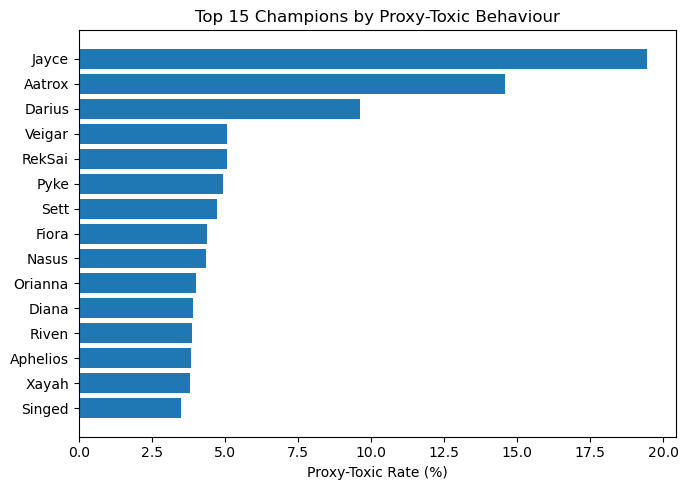

In [ ]:
import matplotlib.pyplot as plt

plot_df = (
    champion_summary
    .sort_values('toxicity_rate_pct', ascending=False)
    .head(15)
    .iloc[::-1]
)

plt.figure(figsize=(7,5))
plt.barh(
    plot_df['CHAMPION NAME_player'],
    plot_df['toxicity_rate_pct']
)

plt.xlabel('Proxy-Toxic Rate (%)')
plt.title('Top 15 Champions by Proxy-Toxic Behaviour')

plt.tight_layout()
plt.show()

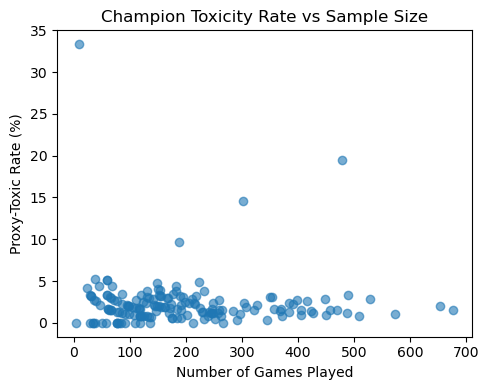

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(
    champion_summary['n_games'],
    champion_summary['toxicity_rate_pct'],
    alpha=0.6
)

plt.xlabel('Number of Games Played')
plt.ylabel('Proxy-Toxic Rate (%)')
plt.title('Champion Toxicity Rate vs Sample Size')

plt.tight_layout()
plt.show()

In [ ]:
champion_summary

,CHAMPION NAME_player,toxicity_rate_pct,n_games,tags,tags_list
0,Aatrox,14.569536,302,['Fighter'],[Fighter]
1,Ahri,1.173709,426,"['Mage', 'Assassin']","[Mage, Assassin]"
2,Akali,1.162791,258,['Assassin'],[Assassin]
3,Akshan,1.010101,99,"['Marksman', 'Assassin']","[Marksman, Assassin]"
4,Alistar,1.481481,405,"['Tank', 'Support']","[Tank, Support]"
...,...,...,...,...,...
164,Zeri,2.985075,134,['Marksman'],[Marksman]
165,Ziggs,3.333333,60,['Mage'],[Mage]
166,Zilean,0.746269,134,"['Support', 'Mage']","[Support, Mage]"
167,Zoe,1.863354,161,['Mage'],[Mage]


tbc: toxicity vs difficulty

=> objective: see which champions are more associated with toxic behaviour + and what are the reasons behind it (eg. number of games played, difficulty level, role, etc.)

#### Proxy-toxic behavior by champions - by champion tags

In [ ]:
import ast

def normalize_tags(x):
    """
    Normalize champion tags into a clean list of strings.
    Handles cases where tags are:
    - a Python list
    - a comma-separated string: "Fighter, Assassin"
    - a stringified list: "['Fighter', 'Assassin']"
    """
    if pd.isna(x):
        return []
    
    # Case 1: already a list
    if isinstance(x, list):
        return [t.strip() for t in x if isinstance(t, str) and t.strip()]
    
    # Case 2: string
    s = str(x).strip()
    if not s:
        return []
    
    # Try parsing stringified list safely
    if s.startswith('[') and s.endswith(']'):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(t).strip() for t in parsed if str(t).strip()]
        except Exception:
            # Fall back to manual parsing if malformed
            pass
    
    # Fall back: comma-separated string
    # Also strip brackets/quotes if they leaked in
    s = s.replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    parts = [p.strip() for p in s.split(',') if p.strip()]
    return parts

In [ ]:

# Build champion-level table first (prevents player-level duplication issues)
champion_summary = (
    df_full_clean.groupby('CHAMPION NAME_player')
      .agg(
          toxicity_rate_pct=('isToxic', lambda s: s.mean() * 100),
          n_games=('isToxic', 'size'),
          tags=('tags_championOverall', 'first')
      )
      .reset_index()
)

# Normalize tags to list[str]
champion_summary['tags_list'] = champion_summary['tags'].apply(normalize_tags)

# Explode tags
tag_summary = (
    champion_summary
    .explode('tags_list')
    .rename(columns={'tags_list': 'tag'})
    .query("tag != ''")
    .groupby('tag')
    .agg(
        avg_toxicity=('toxicity_rate_pct', 'mean'),
        n_champions=('CHAMPION NAME_player', 'nunique')
    )
    .sort_values('avg_toxicity', ascending=False)
)

tag_summary

,avg_toxicity,n_champions
tag,,
Fighter,3.233994,58
Marksman,2.538984,32
Tank,2.261749,44
Mage,2.121178,75
Assassin,1.906832,45
Support,1.595634,43


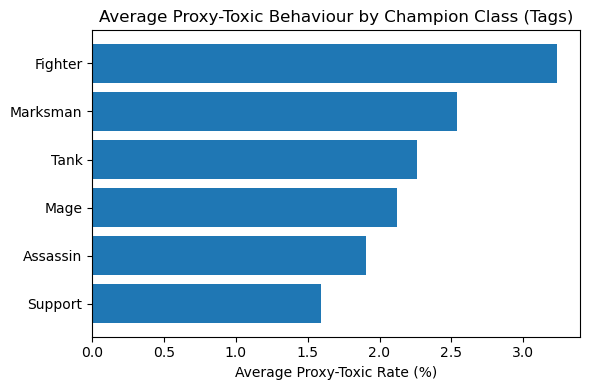

In [ ]:
import matplotlib.pyplot as plt

plot_df = tag_summary.iloc[::-1]

plt.figure(figsize=(6,4))
plt.barh(plot_df.index, plot_df['avg_toxicity'])
plt.xlabel('Average Proxy-Toxic Rate (%)')
plt.title('Average Proxy-Toxic Behaviour by Champion Class (Tags)')
plt.tight_layout()
plt.show()

### 6.3: Clustering (Unsupervised Learning)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)

In [ ]:
# pd.set_option('display.max_columns', None)
# df_full_clean = pd.read_csv('final_cleaned_data_with_proxy_labels_v3.csv')

In [ ]:
# did not include  'CHAMPION NAME_player' as there's too many names and it'll dominate feature space
# did not use 'SURRENDER TIME (MIN)_player' as 'GAME DURATION_player' is sufficient
# Keep 
features = ['WIN_player', 'EARLY SURRENDER_player', 'SURRENDER_player', 'GAME DURATION_player', 
            'TROLL BUILD (15 MIN)_player', 'FLAG', 'KDA RATIO_player', 'KDA DELTA',  'CHAMPION NAME_player',
            'DEATHS_player', 'DEATH SHARE (%)', 'VISION SCORE PER MIN_player',
            'WARDS PLACED_player', 'WARDS KILLED_player', 'CS PER MIN_player',
            'GOLD PER MIN_player', 'KILL PARTICIPATION_player',
            'TEAM DAMAGE (%)_player', 'TURRET KILLS_player',
            'CHAMPION DIFFICULTY_championOverall', 'kills_player', 'assists_player', 'individualPosition_player',
            'totalDamageDealtToChampions_player', 'totalDamageTaken_player',
            'goldEarned_player', 'totalMinionsKilled_player',
            'neutralMinionsKilled_player', 'visionScore_player',
            'inhibitorKills_player', 'firstBloodKill_player',
            'level_15min_player', 'gold_15min_player', 'cs_15min_player']
df_features = df_full_clean[features]

In [ ]:
# Check for missing values
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32812 entries, 0 to 32811
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   WIN_player                           32812 non-null  bool   
 1   EARLY SURRENDER_player               32812 non-null  bool   
 2   SURRENDER_player                     32812 non-null  bool   
 3   GAME DURATION_player                 32812 non-null  int64  
 4   TROLL BUILD (15 MIN)_player          32812 non-null  bool   
 5   FLAG                                 32812 non-null  bool   
 6   KDA RATIO_player                     32812 non-null  float64
 7   KDA DELTA                            32811 non-null  float64
 8   CHAMPION NAME_player                 32812 non-null  object 
 9   DEATHS_player                        32812 non-null  int64  
 10  DEATH SHARE (%)                      32414 non-null  float64
 11  VISION SCORE PER MIN_player 

In [ ]:
# Drop rows with missing values in 'DEATH SHARE (%)', 'level_15min_player', 'gold_15min_player', 'cs_15min_player'
df_features = df_features.dropna(subset=['KDA DELTA', 'DEATH SHARE (%)', 'level_15min_player', 'gold_15min_player', 'cs_15min_player'])

In [ ]:
numeric_cols = ['GAME DURATION_player', 'KDA RATIO_player', 'KDA DELTA', 'DEATHS_player', 'DEATH SHARE (%)', 'VISION SCORE PER MIN_player',
                'WARDS PLACED_player', 'WARDS KILLED_player', 'CS PER MIN_player',
                'GOLD PER MIN_player', 'KILL PARTICIPATION_player', 'TEAM DAMAGE (%)_player', 'TURRET KILLS_player',
                'CHAMPION DIFFICULTY_championOverall', 'kills_player', 'assists_player',
                'totalDamageDealtToChampions_player', 'totalDamageTaken_player',
                'goldEarned_player', 'totalMinionsKilled_player', 'neutralMinionsKilled_player', 'visionScore_player',
                'inhibitorKills_player','level_15min_player', 'gold_15min_player', 'cs_15min_player']
categorical_cols = [c for c in features if c not in numeric_cols]

In [ ]:
scaler = StandardScaler()
df_features[numeric_cols] = scaler.fit_transform(df_features[numeric_cols])

In [ ]:
categorical_encoded = pd.get_dummies(df_features[categorical_cols])

In [ ]:
df_features = df_features.drop(columns=categorical_cols)
df_features = pd.concat([df_features, categorical_encoded], axis=1)

In [ ]:
cluster_labels = kmeans.fit_predict(df_features)

In [ ]:
df_features.insert(0,'CLUSTER LABELS (KMEANS)', cluster_labels)
df_features

,CLUSTER LABELS (KMEANS),GAME DURATION_player,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,level_15min_player,gold_15min_player,cs_15min_player,WIN_player,EARLY SURRENDER_player,SURRENDER_player,TROLL BUILD (15 MIN)_player,FLAG,firstBloodKill_player,CHAMPION NAME_player_Aatrox,CHAMPION NAME_player_Ahri,CHAMPION NAME_player_Akali,CHAMPION NAME_player_Akshan,CHAMPION NAME_player_Alistar,CHAMPION NAME_player_Ambessa,CHAMPION NAME_player_Amumu,CHAMPION NAME_player_Anivia,CHAMPION NAME_player_Annie,CHAMPION NAME_player_Aphelios,CHAMPION NAME_player_Ashe,CHAMPION NAME_player_AurelionSol,CHAMPION NAME_player_Aurora,CHAMPION NAME_player_Azir,CHAMPION NAME_player_Bard,CHAMPION NAME_player_Belveth,CHAMPION NAME_player_Blitzcrank,CHAMPION NAME_player_Brand,CHAMPION NAME_player_Braum,CHAMPION NAME_player_Briar,CHAMPION NAME_player_Caitlyn,CHAMPION NAME_player_Camille,CHAMPION NAME_player_Cassiopeia,CHAMPION NAME_player_Chogath,CHAMPION NAME_player_Corki,CHAMPION NAME_player_Darius,CHAMPION NAME_player_Diana,CHAMPION NAME_player_DrMundo,CHAMPION NAME_player_Draven,CHAMPION NAME_player_Ekko,CHAMPION NAME_player_Elise,CHAMPION NAME_player_Evelynn,CHAMPION NAME_player_Ezreal,CHAMPION NAME_player_FiddleSticks,CHAMPION NAME_player_Fiora,CHAMPION NAME_player_Fizz,CHAMPION NAME_player_Galio,CHAMPION NAME_player_Gangplank,CHAMPION NAME_player_Garen,CHAMPION NAME_player_Gnar,CHAMPION NAME_player_Gragas,CHAMPION NAME_player_Graves,CHAMPION NAME_player_Gwen,CHAMPION NAME_player_Hecarim,CHAMPION NAME_player_Heimerdinger,CHAMPION NAME_player_Hwei,CHAMPION NAME_player_Illaoi,CHAMPION NAME_player_Irelia,CHAMPION NAME_player_Ivern,CHAMPION NAME_player_Janna,CHAMPION NAME_player_JarvanIV,CHAMPION NAME_player_Jax,CHAMPION NAME_player_Jayce,CHAMPION NAME_player_Jhin,CHAMPION NAME_player_Jinx,CHAMPION NAME_player_KSante,CHAMPION NAME_player_Kaisa,CHAMPION NAME_player_Kalista,CHAMPION NAME_player_Karma,CHAMPION NAME_player_Karthus,CHAMPION NAME_player_Kassadin,CHAMPION NAME_player_Katarina,CHAMPION NAME_player_Kayle,CHAMPION NAME_player_Kayn,CHAMPION NAME_player_Kennen,CHAMPION NAME_player_Khazix,CHAMPION NAME_player_Kindred,CHAMPION NAME_player_Kled,CHAMPION NAME_player_KogMaw,CHAMPION NAME_player_Leblanc,CHAMPION NAME_player_LeeSin,CHAMPION NAME_player_Leona,CHAMPION NAME_player_Lillia,CHAMPION NAME_player_Lissandra,CHAMPION NAME_player_Lucian,CHAMPION NAME_player_Lulu,CHAMPION NAME_player_Lux,CHAMPION NAME_player_Malphite,CHAMPION NAME_player_Malzahar,CHAMPION NAME_player_Maokai,CHAMPION NAME_player_MasterYi,CHAMPION NAME_player_Mel,CHAMPION NAME_player_Milio,CHAMPION NAME_player_MissFortune,CHAMPION NAME_player_Mordekaiser,CHAMPION NAME_player_Morgana,CHAMPION NAME_player_Naafiri,CHAMPION NAME_player_Nami,CHAMPION NAME_player_Nasus,CHAMPION NAME_player_Nautilus,CHAMPION NAME_player_Neeko,CHAMPION NAME_player_Nidalee,CHAMPION NAME_player_Nilah,CHAMPION NAME_player_Nocturne,CHAMPION NAME_player_Nunu,CHAMPION NAME_player_Olaf,CHAMPION NAME_player_Orianna,CHAMPION NAME_player_Ornn,CHAMPION NAME_player_Pantheon,CHAMPION NAME_player_Poppy,CHAMPION NAME_player_Pyke,CHAMPION NAME_player_Qiyana,CHAMPION NAME_player_Quinn,CHAMPION NAME_player_Rakan,CHAMPION NAME_player_Rammus,CHAMPION NAME_player_RekSai,CHAMPION NAME_player_Rell,CHAMPION NAME_player_Renata,CHAMPION NAME_player_Renekton,CHAMPION NAME_player_Rengar,CHAMPION NAME_player_Riven,CHAMPION NAME_player_Rumble,CHAMPION NAME_player_Ryze,CHAMPION NAME_player_Samira,CHAMPION NAME_player_Sejuani,CHAMPION NAME_player_Senna,CHAMPION NAME_player_Seraphine,CHAMPION NAME_player_Sett,CHAMPION NAME_player

In [ ]:
df_full_clean.loc[df_features.index, 'CLUSTER LABELS (KMEANS)'] = df_features['CLUSTER LABELS (KMEANS)']
df_full_clean.insert(0, 'CLUSTER LABELS (KMEANS)', df_full_clean.pop('CLUSTER LABELS (KMEANS)'))

In [ ]:
df_full_clean

,CLUSTER LABELS (KMEANS),PROXY TOXIC LABEL,TEAM,matchId_player,WIN_player,CHAMPION NAME_player,EARLY SURRENDER_player,SURRENDER_player,SURRENDER TIME (MIN)_player,GAME DURATION_player,TROLL BUILD (15 MIN)_player,FLAG,KDA RATIO_player,KDA DELTA,DEATHS_player,DEATH SHARE (%),VISION SCORE PER MIN_player,WARDS PLACED_player,WARDS KILLED_player,CS PER MIN_player,GOLD PER MIN_player,KILL PARTICIPATION_player,TEAM DAMAGE (%)_player,TURRET KILLS_player,CHAMPION DIFFICULTY_championOverall,kills_player,assists_player,teamPosition_player,individualPosition_player,totalDamageDealtToChampions_player,totalDamageTaken_player,goldEarned_player,totalMinionsKilled_player,neutralMinionsKilled_player,visionScore_player,inhibitorKills_player,firstBloodKill_player,items_15min_player,level_15min_player,gold_15min_player,cs_15min_player,games_played_championPosition,kda_championPosition,win_rate_championPosition,pick_rate_championPosition,ban_rate_championPosition,cs_championPosition,gold_championPosition,tags_championOverall,partype_championOverall,attack_championOverall,defense_championOverall,magic_championOverall,hp_championOverall,hpperlevel_championOverall,mp_championOverall,mpperlevel_championOverall,movespeed_championOverall,armor_championOverall,armorperlevel_championOverall,spellblock_championOverall,spellblockperlevel_championOverall,attackrange_championOverall,hpregen_championOverall,hpregenperlevel_championOverall,mpregen_championOverall,mpregenperlevel_championOverall,attackdamage_championOverall,attackdamageperlevel_championOverall,attackspeedperlevel_championOverall,attackspeed_championOverall
0,1.0,False,1,NA1_5269865992,True,Yasuo,False,True,23.333333,1400,False,False,7.000000,5.760000,1,6.666667,0.514286,9,1,9.857143,467.828571,0.333333,0.147033,2,10,4,3,TOP,top,12816,14985,10916,225,5,12,0,False,"1055,2031,3006,3363,3153,1018",11.0,6539.0,136.0,47.0,1.24,38.297872,2.47,16.33,218.72,11248.0,"['Fighter', 'Assassin']",Flow,8,4,4,590.0,110.0,100.0,0.0,345.0,32.0,4.60,32.0,2.05,175.0,6.50,0.90,0.00,0.00,60.0,2.50,3.50,0.697
1,1.0,False,1,NA1_5269865992,True,Nasus,False,True,23.333333,1400,False,False,12.000000,10.080000,1,6.666667,0.642857,8,1,7.800000,397.671429,0.571429,0.233012,0,6,5,7,MIDDLE,middle,20310,21173,9279,180,2,15,0,False,"1056,3009,2031,3078,3363",10.0,5639.0,118.0,11.0,1.92,45.454545,0.74,0.12,189.09,10748.0,"['Fighter', 'Tank']",Mana,7,5,6,631.0,104.0,326.0,62.0,350.0,34.0,4.70,32.0,2.05,125.0,9.00,0.90,7.45,0.50,67.0,4.00,3.48,0.638
2,1.0,False,1,NA1_5269865992,True,Sylas,False,True,23.333333,1400,False,False,16.000000,13.190000,1,6.666667,0.728571,4,1,7.285714,433.628571,0.761905,0.212927,1,5,5,11,JUNGLE,jungle,18560,30340,10118,11,159,17,0,False,"1102,1082,3364,6653,1052,2022",10.0,5792.0,104.0,113.0,2.81,48.672566,3.65,12.21,171.29,11944.0,"['Mage', 'Assassin']",Mana,3,4,8,600.0,122.0,400.0,70.0,340.0,29.0,5.20,32.0,2.55,175.0,9.00,0.90,8.00,0.80,61.0,3.00,3.50,0.645
3,1.0,False,1,NA1_5269865992,True,Draven,False,True,23.333333,1400,False,False,1.571429,-0.468571,7,46.666667,0.300000,7,0,7.842857,381.557143,0.523810,0.162800,1,8,1,10,BOTTOM,bottom,14190,14449,8903,175,8,7,0,False,"1055,1001,3072,1042,1042,3363",9.0,5170.0,129.0,237.0,2.04,49.789030,7.20,31.64,213.86,13787.0,['Marksman'],Mana,9,3,1,675.0,104.0,361.0,39.0,330.0,29.0,4.50,30.0,1.30,550.0,3.75,0.70,8.05,0.65,62.0,3.60,2.70,0.679
4,0.0,False,1,NA1_5269865992,True,Swain,False,True,23.333333,1400,False,False,3.600000,2.590000,5,33.333333,2.400000,24,4,1.414286,359.485714,0.857143,0.244229,0,8,6,12,UTILITY,support,21288,26427,8388,33,0,56,0,False,"3070,3364,3116,1001,2031,2055",8.0,5228.0,19.0,7.0,1.01,14.285714,0.91,0.22,42.71,7651.0,"['Mage', 'Support']",Mana,2,6,9,595.0,99.0,400.0,29.0,330.0,25.0,4.70,31.0,1.55,525.0,3.00,0.50,10.00,0.80,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [ ]:
df_full_clean['CLUSTER LABELS (KMEANS)'].value_counts()

CLUSTER LABELS (KMEANS)
1.0    25700
0.0     6445
Name: count, dtype: int64

In [ ]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32812 entries, 0 to 32811
Data columns (total 71 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   CLUSTER LABELS (KMEANS)               32145 non-null  float64
 1   PROXY TOXIC LABEL                     32812 non-null  bool   
 2   TEAM                                  32812 non-null  int64  
 3   matchId_player                        32812 non-null  object 
 4   WIN_player                            32812 non-null  bool   
 5   CHAMPION NAME_player                  32812 non-null  object 
 6   EARLY SURRENDER_player                32812 non-null  bool   
 7   SURRENDER_player                      32812 non-null  bool   
 8   SURRENDER TIME (MIN)_player           12322 non-null  float64
 9   GAME DURATION_player                  32812 non-null  int64  
 10  TROLL BUILD (15 MIN)_player           32812 non-null  bool   
 11  FLAG           

In [ ]:
# Select key features
key_features = ['CLUSTER LABELS (KMEANS)',
                'KDA RATIO_player',
                'DEATHS_player',
                'DEATH SHARE (%)',
                'VISION SCORE PER MIN_player',
                'WARDS PLACED_player',
                'WARDS KILLED_player',
                'CS PER MIN_player',
                'GOLD PER MIN_player',
                'KILL PARTICIPATION_player',
                'TEAM DAMAGE (%)_player', 
                'TURRET KILLS_player', 
                'CHAMPION DIFFICULTY_championOverall'
]

# Create pairplot with KDE on diagonal
sns.pairplot(df_full_clean[key_features], 
             hue='CLUSTER LABELS (KMEANS)',
             diag_kind='kde',  # KDE on diagonal
             plot_kws={'alpha': 0.5, 's': 20},
             corner=True)  # Only lower triangle
plt.suptitle('Cluster Comparison Matrix', y=1.01)

<Axes: ylabel='CHAMPION NAME_player'>

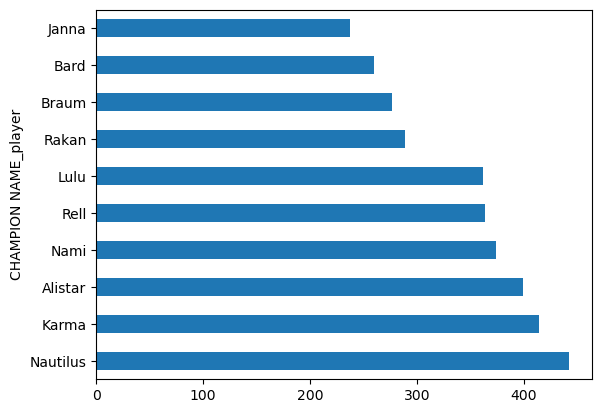

In [ ]:
df_full_clean.loc[df_full_clean['CLUSTER LABELS (KMEANS)']==0.0,'CHAMPION NAME_player'].value_counts().head(10).plot(kind='barh')

In [ ]:
# split by position...

In [ ]:
# Save to CSV for analysis
# df_full_clean.to_csv("data_with_kmeans_labels_v4.csv", index=False)
# print("Saved file: data_with_kmeans_labels_v4.csv")

Saved file: data_with_kmeans_labels_v4.csv
